## Cargar Datos

    Cargamos las librerias

In [440]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

    Cargamos los datos

In [441]:
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
# Load datos
path_datos = os.path.join('Datos','Transformados')
filename = os.path.join(path_datos,'df_limpio.csv')
df = pd.read_csv(filename)
df['is_cancelled'] = df['status'] == 'cancelled'
#print(df.head())

    Visualizar las columnas

In [442]:
df.columns

Index(['booked_at', 'checkin_time', 'checkout_time', 'lead_time',
       'lenght_of_stay', 'checkin_month', 'checkin_day', 'adult_count',
       'child_count', 'origin', 'travel_agency_name', 'requested_category',
       'requested_category_name', 'asset', 'asset_type', 'brand',
       'asset_opening_date', 'available_units', 'business_segment', 'rate',
       'rate_group_name', 'rate_type', 'completed_entry_forms_count',
       'all_entry_forms_completed', 'last_entry_form_completed_at',
       'returning_inhabitant', 'recurrence', 'libere_community',
       'bought_products', 'product_count', 'reservation_net_value',
       'total_adr', 'status', 'cancelled_at', 'cancellation_reason',
       'cancellation_lead_time', 'ciudad', 'mes_cancelacion',
       'estacion_cancelacion', 'mes_estancia', 'estacion_estancia',
       'mes_reserva', 'estacion_reserva', 'dia_semana_reserva',
       'dia_semana_reserva_nombre', 'dia_semana_cancelacion',
       'dia_semana_cancelacion_nombre', 'dia_sem

     Paleta de colores

In [443]:
libere_true_graph_palette = ["#1C1C1C", # Negro profundo (texto / baseline)
                             "#6B5E4B", # Marrón piedra (materiales, madera)    
                             "#B89B72", # Arena cálida (marca, acento)    
                             "#3F5C6E", # Azul acero urbano    
                             "#8FA6A0", # Verde grisáceo suave    
                             "#C46A4A", # Terracota elegante (muy Líbere)    
                             "#9A8F86", # Gris cálido medio    
                             "#D8D1C6" # Gris claro cálido (fondos secundarios)
                             ]

## Libere Graficos

    Análisis de Cancelaciones de Reservas 

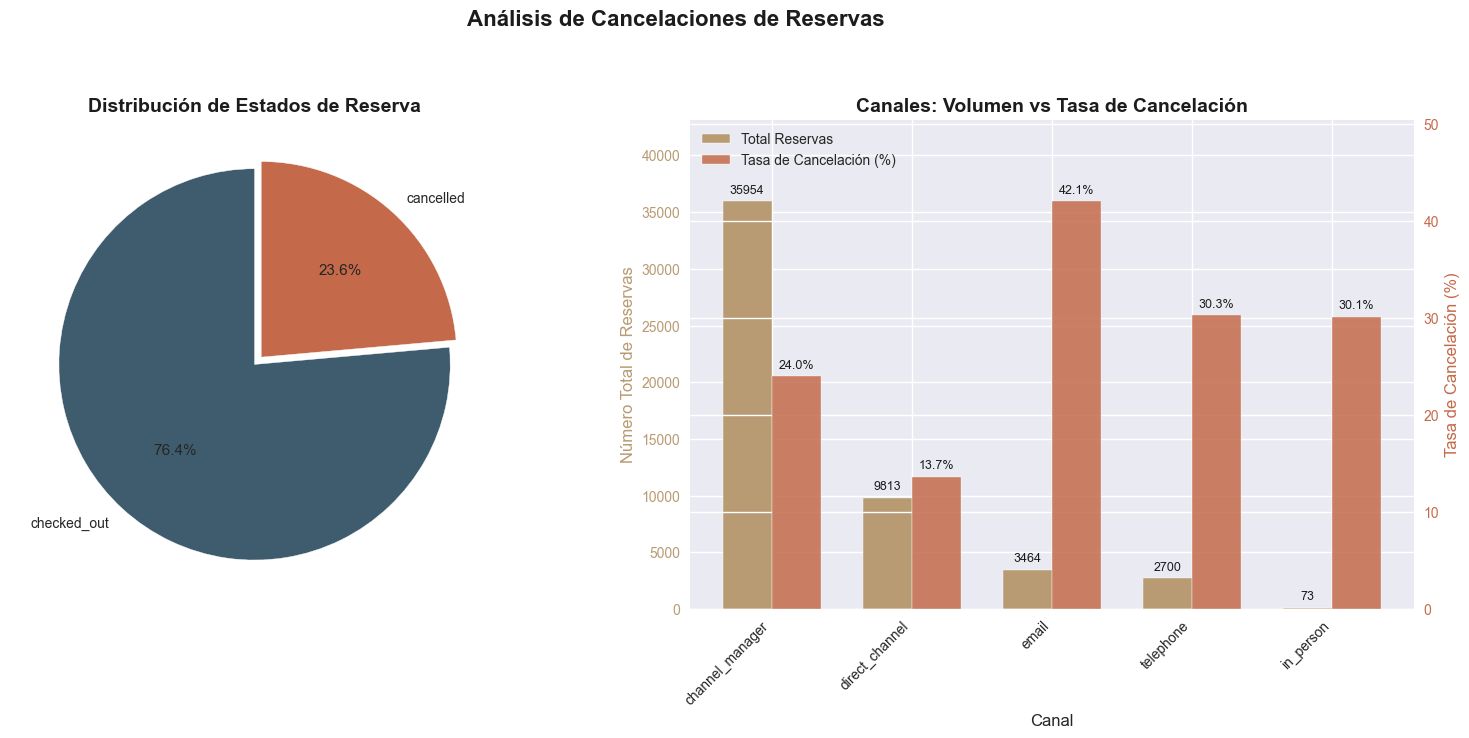

In [444]:
# FIGURA
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# GRÁFICO 1: DISTRIBUCIÓN DE ESTADOS (PIE)
status_counts = df['status'].value_counts()

axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05 if s == 'cancelled' else 0 for s in status_counts.index],
    colors=[
        libere_true_graph_palette[3],  # Azul acero
        libere_true_graph_palette[5]   # Terracota
    ]
)

axes[0].set_title(
    'Distribución de Estados de Reserva',
    fontsize=14,
    fontweight='bold',
    color=libere_true_graph_palette[0]
)

# GRÁFICO 2: CANALES – VOLUMEN VS CANCELACIÓN
if 'origin' in df.columns:

    # Top 8 canales
    top_channels = df['origin'].value_counts().head(8).index
    df_top = df[df['origin'].isin(top_channels)]

    channel_stats = pd.DataFrame({
        'total_reservations': df_top['origin'].value_counts(),
        'cancellation_rate': df_top.groupby('origin')['is_cancelled'].mean() * 100
    }).reindex(top_channels)

    x = range(len(channel_stats))
    width = 0.35

    ax1 = axes[1]

    # Volumen
    bars1 = ax1.bar(
        [i - width/2 for i in x],
        channel_stats['total_reservations'],
        width,
        label='Total Reservas',
        color=libere_true_graph_palette[2]  # Arena
    )

    ax1.set_xlabel('Canal', fontsize=12)
    ax1.set_ylabel(
        'Número Total de Reservas',
        fontsize=12,
        color=libere_true_graph_palette[2]
    )
    ax1.tick_params(axis='y', labelcolor=libere_true_graph_palette[2])

    ax1.set_xticks(x)
    ax1.set_xticklabels(
        channel_stats.index,
        rotation=45,
        ha='right',
        fontsize=10
    )

    # Segundo eje
    ax2 = ax1.twinx()

    bars2 = ax2.bar(
        [i + width/2 for i in x],
        channel_stats['cancellation_rate'],
        width,
        label='Tasa de Cancelación (%)',
        color=libere_true_graph_palette[5],  # Terracota
        alpha=0.85
    )

    ax2.set_ylabel(
        'Tasa de Cancelación (%)',
        fontsize=12,
        color=libere_true_graph_palette[5]
    )
    ax2.tick_params(axis='y', labelcolor=libere_true_graph_palette[5])

    # Etiquetas en barras
    for i, (v1, v2) in enumerate(
        zip(channel_stats['total_reservations'], channel_stats['cancellation_rate'])
    ):
        ax1.text(
            i - width/2,
            v1 + max(channel_stats['total_reservations']) * 0.02,
            f'{int(v1)}',
            ha='center',
            fontsize=9,
            color=libere_true_graph_palette[0]
        )

        ax2.text(
            i + width/2,
            v2 + max(channel_stats['cancellation_rate']) * 0.02,
            f'{v2:.1f}%',
            ha='center',
            fontsize=9,
            color=libere_true_graph_palette[0]
        )

    # Leyenda combinada
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        frameon=False
    )

    ax1.set_title(
        'Canales: Volumen vs Tasa de Cancelación',
        fontsize=14,
        fontweight='bold',
        color=libere_true_graph_palette[0]
    )

    ax1.set_ylim(0, channel_stats['total_reservations'].max() * 1.2)
    ax2.set_ylim(0, channel_stats['cancellation_rate'].max() * 1.2)

else:
    axes[1].text(
        0.5, 0.5,
        'Columna "origin" no encontrada',
        ha='center',
        va='center',
        fontsize=12
    )

# TÍTULO GENERAL Y LAYOUT
plt.suptitle(
    'Análisis de Cancelaciones de Reservas',
    fontsize=16,
    fontweight='bold',
    color=libere_true_graph_palette[0],
    y=1.05
)

plt.tight_layout()
plt.show()

    TABLA ADICIONAL: Datos de los canales 

In [445]:
if 'origin' in df.columns:
    print("\n" + "="*60)
    print("RESUMEN DE CANALES (Top 8 por volumen)")
    print("="*60)
    
    channel_summary = pd.DataFrame({
        'Total Reservas': channel_stats['total_reservations'].astype(int),
        'Tasa Cancelación (%)': channel_stats['cancellation_rate'].round(1),
        '% del Total': (channel_stats['total_reservations'] / len(df) * 100).round(1)
    })
    
    print(channel_summary)
    print("\nResumen general:")
    print(f"- Total de reservas analizadas: {len(df)}")
    print(f"- Tasa general de cancelación: {(df['is_cancelled'].sum() / len(df) * 100):.1f}%")
    print(f"- Número de canales únicos: {df['origin'].nunique()}")


RESUMEN DE CANALES (Top 8 por volumen)
                 Total Reservas  Tasa Cancelación (%)  % del Total
origin                                                            
channel_manager           35954                  24.0         69.1
direct_channel             9813                  13.7         18.9
email                      3464                  42.1          6.7
telephone                  2700                  30.3          5.2
in_person                    73                  30.1          0.1

Resumen general:
- Total de reservas analizadas: 52004
- Tasa general de cancelación: 23.6%
- Número de canales únicos: 5


    Distribución porcentual y de cancelaciones de pertenencia a Líbere 

C:\Users\unaip\AppData\Local\Temp\ipykernel_10372\701567601.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


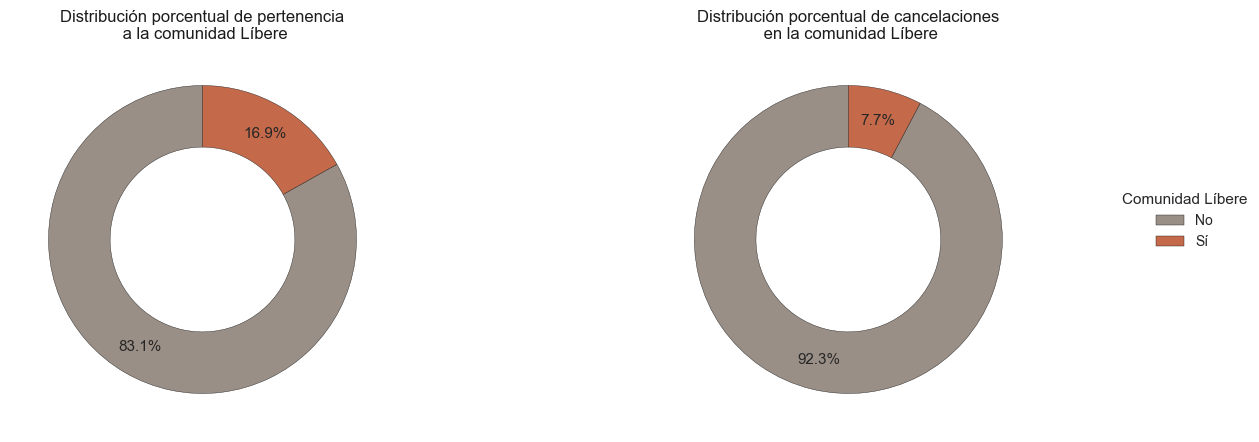

In [446]:
# Colores para la comunidad (No / Sí)
colores_comunidad = ["#9A8F86", "#C46A4A"]  # No = gris cálido | Sí = terracota Líbere

# Datos comunidad Líbere
comunidad_libere = (
    df.groupby('libere_community')
      .size()
      .to_frame()
      .reset_index()
      .rename(columns={0: 'total'})
)

# Mapear valores numéricos a texto
comunidad_libere['libere_community'] = comunidad_libere['libere_community'].map({'no': 'No', 'yes': 'Sí'})

# Cancelaciones
df_cancelaciones = df[df['status'] == 'cancelled']

comunidad_libere_cancelados = (
    df_cancelaciones.groupby('libere_community')
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: 'cancelados'})
)

# Mapear valores numéricos a texto
comunidad_libere_cancelados['libere_community'] = comunidad_libere_cancelados['libere_community'].map({'no': 'No', 'yes': 'Sí'})

# Merge y proporción
comunidad_libere_merged = pd.merge(
    comunidad_libere,
    comunidad_libere_cancelados,
    on='libere_community'
)

comunidad_libere_merged['prop'] = (
    comunidad_libere_merged['cancelados'] * 100 / comunidad_libere_merged['total']
)

# Visualización
sns.set_style("whitegrid")

fig7, ax7 = plt.subplots(
    1, 2,
    figsize=(15, 5),
    gridspec_kw={'wspace': 0.25}
)

# --- Pie 1: Distribución comunidad ---
ax7[0].pie(
    comunidad_libere['total'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80,
    colors=colores_comunidad,
    wedgeprops=dict(
        width=0.4,
        edgecolor=libere_true_graph_palette[0]
    )
)

ax7[0].set_title(
    'Distribución porcentual de pertenencia\n a la comunidad Líbere',
    fontsize=12,
    color=libere_true_graph_palette[0]
)

# --- Pie 2: Cancelaciones ---
ax7[1].pie(
    comunidad_libere_cancelados['cancelados'],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80,
    colors=colores_comunidad,
    wedgeprops=dict(
        width=0.4,
        edgecolor=libere_true_graph_palette[0]
    )
)

ax7[1].set_title(
    'Distribución porcentual de cancelaciones\n en la comunidad Líbere',
    fontsize=12,
    color=libere_true_graph_palette[0]
)

# Estética final
sns.despine(left=True, bottom=True)

# CORRECCIÓN: Usar los valores correctos para la leyenda
fig7.legend(
    comunidad_libere['libere_community'].tolist(),  # ['No', 'Sí']
    loc='center right',
    title='Comunidad Líbere',
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()

    Razones de cancelación

ESTADÍSTICAS DE RAZONES DE CANCELACIÓN
Total de cancelaciones: 12405
Cancelaciones 'refuse_to_detail': 8495 (68.5%)
Cancelaciones analizadas: 3910

 • payment_missed: 1100 (28.1%)
 • series_group_cancelled: 652 (16.7%)
 • changed_plans: 596 (15.2%)
 • no_show: 511 (13.1%)
 • other: 480 (12.3%)
 • duplicated: 116 (3.0%)
 • force_majeure: 107 (2.7%)
 • technical_error: 88 (2.3%)
 • mistake: 78 (2.0%)
 • found_better_price: 51 (1.3%)


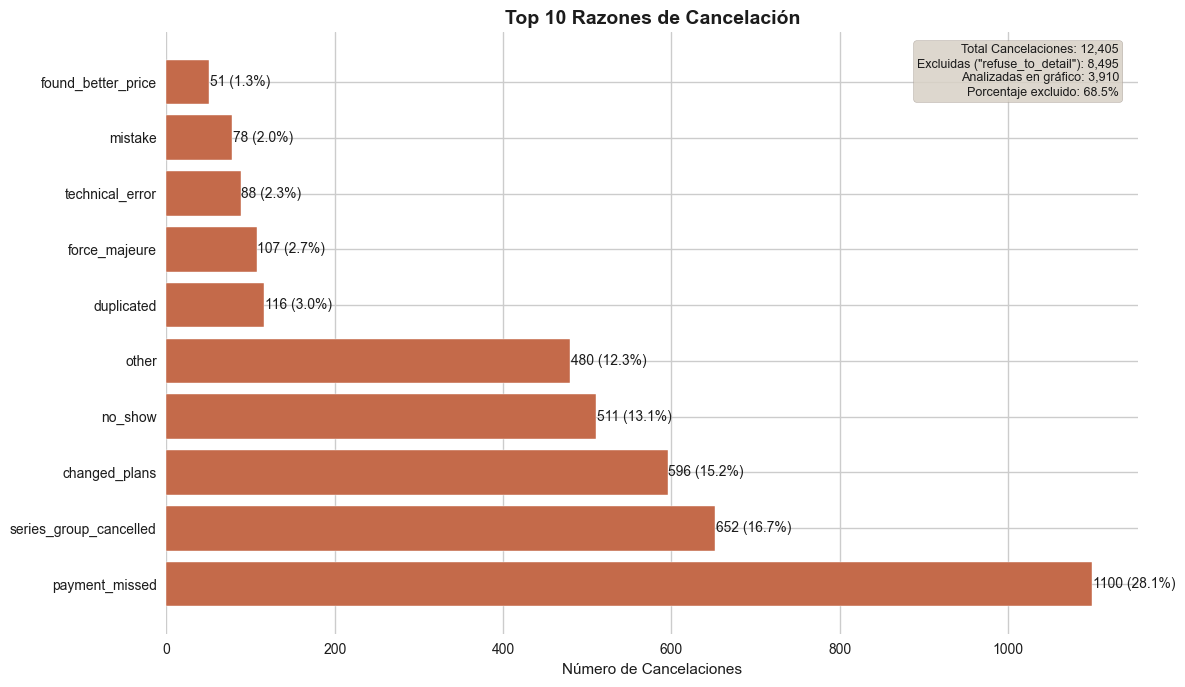

In [447]:
# Configuración visual global
plt.rcParams.update({
    "axes.edgecolor": libere_true_graph_palette[0],
    "axes.labelcolor": libere_true_graph_palette[0],
    "xtick.color": libere_true_graph_palette[0],
    "ytick.color": libere_true_graph_palette[0],
    "text.color": libere_true_graph_palette[0],
    "font.size": 11
})

# GRÁFICO: Razones de Cancelación (sin refuse_to_detail)
plt.figure(figsize=(12, 7))

if 'cancellation_reason' in cancelled_df.columns and not cancelled_df.empty:

    cancelled_filtered = cancelled_df[
        cancelled_df['cancellation_reason'] != 'refuse_to_detail'
    ]

    if not cancelled_filtered.empty:

        reason_counts = cancelled_filtered['cancellation_reason'].value_counts()
        top_n = min(10, len(reason_counts))
        reason_counts = reason_counts.head(top_n)

        bars = plt.barh(
            range(len(reason_counts)),
            reason_counts.values,
            color=libere_true_graph_palette[5]  # Terracota
        )

        plt.yticks(range(len(reason_counts)), reason_counts.index)
        plt.xlabel('Número de Cancelaciones')
        plt.title(
            f'Top {top_n} Razones de Cancelación',
            fontsize=14,
            fontweight='bold'
        )

        # Etiquetas de valores
        for bar, count in zip(bars, reason_counts.values):
            percentage = (count / len(cancelled_filtered)) * 100
            plt.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f'{count} ({percentage:.1f}%)',
                va='center',
                fontsize=10
            )

        # Estadísticas
        total_cancelled = len(cancelled_df)
        total_refused = (cancelled_df['cancellation_reason'] == 'refuse_to_detail').sum()
        total_filtered = len(cancelled_filtered)

        stats_text = (
            f"Total Cancelaciones: {total_cancelled:,}\n"
            f'Excluidas ("refuse_to_detail"): {total_refused:,}\n'
            f"Analizadas en gráfico: {total_filtered:,}\n"
            f"Porcentaje excluido: {(total_refused / total_cancelled * 100):.1f}%"
        )

        plt.text(
            0.98, 0.98,
            stats_text,
            transform=plt.gca().transAxes,
            fontsize=9,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(
                boxstyle='round',
                facecolor=libere_true_graph_palette[7],
                edgecolor=libere_true_graph_palette[6],
                alpha=0.85
            )
        )

        # Consola
        print("=" * 60)
        print("ESTADÍSTICAS DE RAZONES DE CANCELACIÓN")
        print("=" * 60)
        print(f"Total de cancelaciones: {total_cancelled}")
        print(f"Cancelaciones 'refuse_to_detail': {total_refused} ({(total_refused/total_cancelled*100):.1f}%)")
        print(f"Cancelaciones analizadas: {total_filtered}\n")

        for reason, count in reason_counts.items():
            percentage = (count / total_filtered) * 100
            print(f" • {reason}: {count} ({percentage:.1f}%)")

    else:
        print("No hay datos tras excluir 'refuse_to_detail'")

else:
    print("No hay datos de razones de cancelación")

plt.tight_layout()
plt.show()

In [448]:
df['origin'].value_counts()

origin
channel_manager    35954
direct_channel      9813
email               3464
telephone           2700
in_person             73
Name: count, dtype: int64

    Recuento de reservas y cancelaciones

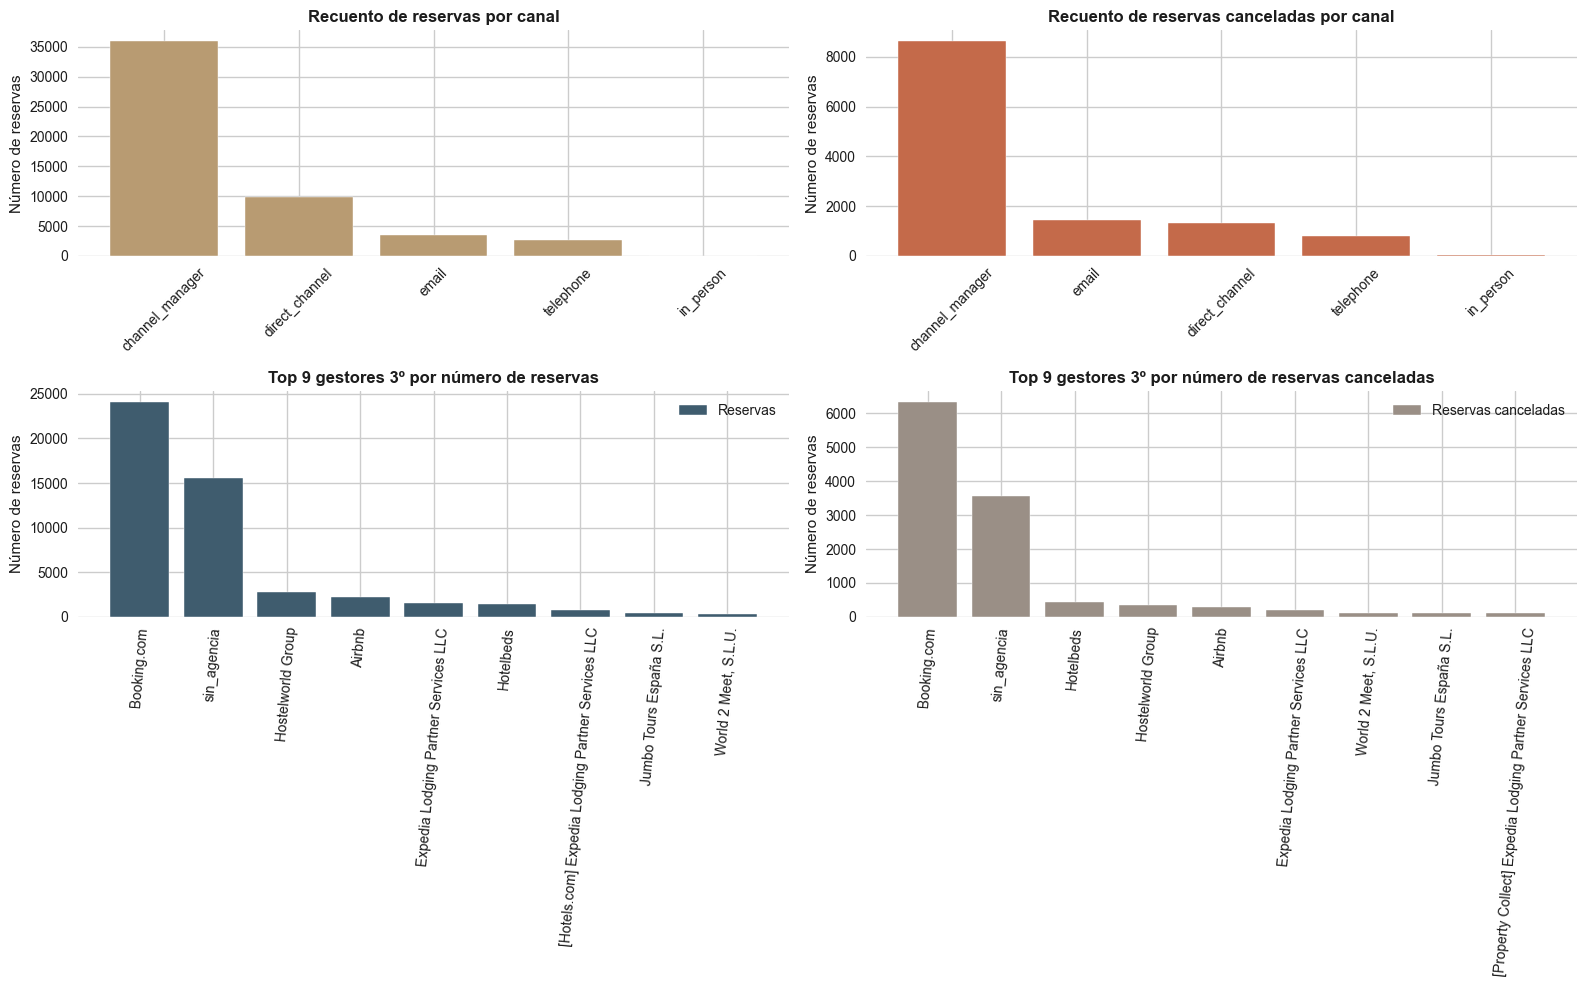

In [449]:
# Configuración visual global
plt.rcParams.update({
    "axes.edgecolor": libere_true_graph_palette[0],
    "axes.labelcolor": libere_true_graph_palette[0],
    "xtick.color": libere_true_graph_palette[0],
    "ytick.color": libere_true_graph_palette[0],
    "text.color": libere_true_graph_palette[0],
    "font.size": 11
})

# Figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Recuento de reservas por canal
reservas_por_canal = df["origin"].value_counts()

axes[0, 0].bar(
    reservas_por_canal.index,
    reservas_por_canal.values,
    color=libere_true_graph_palette[2]  # Arena cálida
)

axes[0, 0].set_title("Recuento de reservas por canal", fontweight="bold")
axes[0, 0].set_ylabel("Número de reservas")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Recuento de reservas canceladas por canal
canceladas_por_canal = df[df["status"] == "cancelled"]["origin"].value_counts()

axes[0, 1].bar(
    canceladas_por_canal.index,
    canceladas_por_canal.values,
    color=libere_true_graph_palette[5]  # Terracota
)

axes[0, 1].set_title("Recuento de reservas canceladas por canal", fontweight="bold")
axes[0, 1].set_ylabel("Número de reservas")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Top 9 gestores 3º por número de reservas
gestor3_reservas = (
    df[df["travel_agency_name"].notna()]
    ["travel_agency_name"]
    .value_counts()
    .head(9)
)

axes[1, 0].bar(
    gestor3_reservas.index,
    gestor3_reservas.values,
    color=libere_true_graph_palette[3],  # Azul acero
    label="Reservas"
)

axes[1, 0].set_title("Top 9 gestores 3º por número de reservas", fontweight="bold")
axes[1, 0].set_ylabel("Número de reservas")
axes[1, 0].tick_params(axis="x", rotation=85)
axes[1, 0].legend(frameon=False)

# 4. Top 9 gestores 3º por número de reservas canceladas
gestor3_canceladas = (
    df[
        (df["travel_agency_name"].notna()) &
        (df["status"] == "cancelled")
    ]["travel_agency_name"]
    .value_counts()
    .head(9)
)

axes[1, 1].bar(
    gestor3_canceladas.index,
    gestor3_canceladas.values,
    color=libere_true_graph_palette[6],  # Gris cálido medio
    label="Reservas canceladas"
)

axes[1, 1].set_title(
    "Top 9 gestores 3º por número de reservas canceladas",
    fontweight="bold"
)
axes[1, 1].set_ylabel("Número de reservas")
axes[1, 1].tick_params(axis="x", rotation=85)
axes[1, 1].legend(frameon=False)

# Ajuste final
plt.tight_layout()
plt.show()

    Volumen de Reservas y Tasa de Cancelación por Tipo de Habitación 

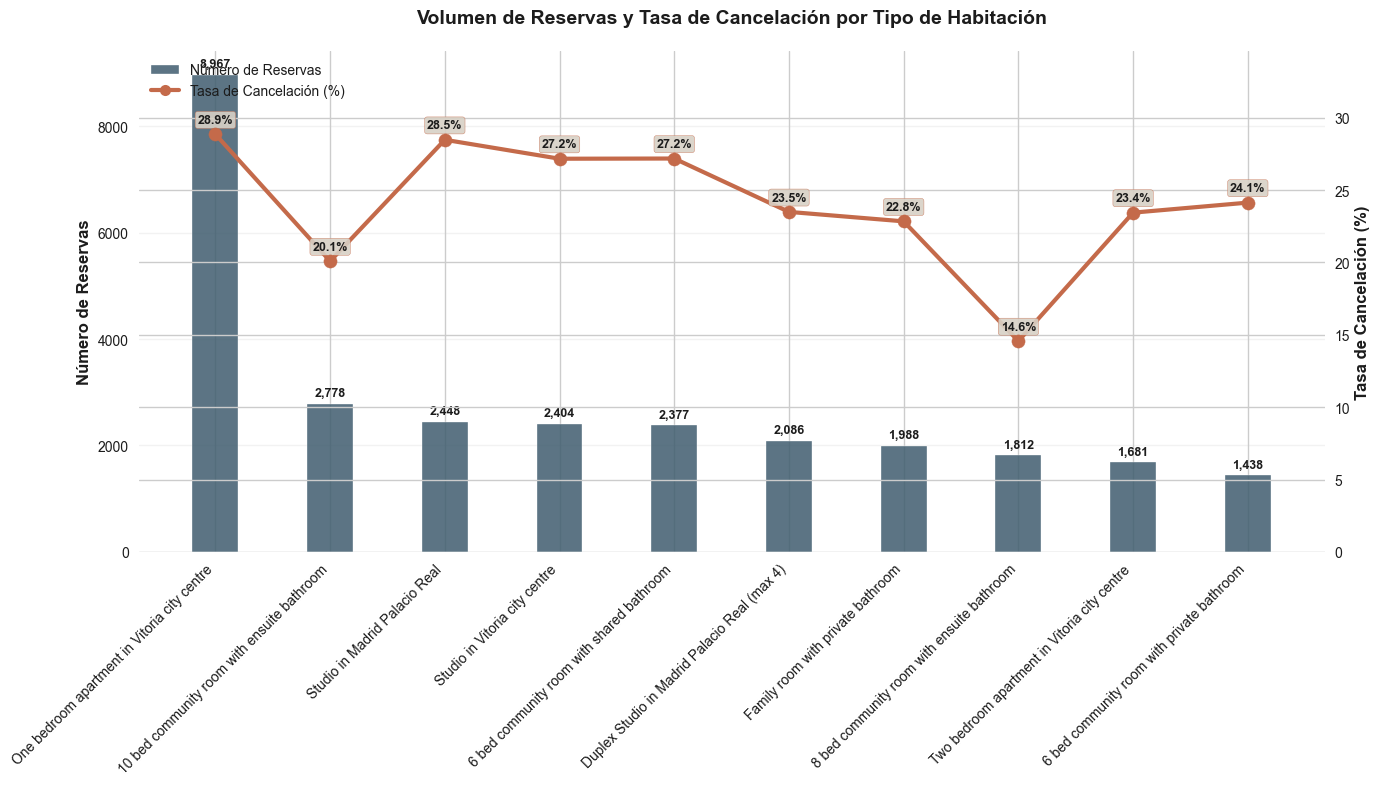

In [450]:
# Cargar datos
path_datos = os.path.join('Datos','Originales')
filename = os.path.join(path_datos,'cancellation_data.csv')
df = pd.read_csv(filename)
df['is_cancelled'] = df['status'] == 'cancelled'

# Convertir ADR a numérico
df['total_adr'] = pd.to_numeric(df['total_adr'], errors='coerce')

# Gráfico combinado
fig, ax = plt.subplots(figsize=(14, 8))

if 'requested_category_name' in df.columns:

    room_counts = df['requested_category_name'].value_counts().head(10)
    cancel_by_room = (
        df.groupby('requested_category_name')['is_cancelled']
        .mean() * 100
    )

    cancel_by_room = cancel_by_room.loc[room_counts.index]
    x = np.arange(len(room_counts))

    # Eje secundario
    ax2 = ax.twinx()

    # Barras: volumen de reservas
    bars1 = ax.bar(
        x,
        room_counts.values,
        width=0.4,
        color=libere_true_graph_palette[3],  
        alpha=0.85,
        label='Número de Reservas'
    )

    # Línea: tasa de cancelación
    line1 = ax2.plot(
        x,
        cancel_by_room.values,
        color=libere_true_graph_palette[5],  # Terracota
        linewidth=3,
        marker='o',
        markersize=8,
        label='Tasa de Cancelación (%)'
    )

    ax2.scatter(
        x,
        cancel_by_room.values,
        color=libere_true_graph_palette[5],
        s=90,
        zorder=5
    )

    # Eje X
    ax.set_xticks(x)
    ax.set_xticklabels(
        room_counts.index,
        rotation=45,
        ha='right',
        fontsize=10
    )

    # Eje Y izquierdo
    ax.set_ylabel(
        'Número de Reservas',
        fontsize=12,
        fontweight='bold'
    )

    # Eje Y derecho
    ax2.set_ylabel(
        'Tasa de Cancelación (%)',
        fontsize=12,
        fontweight='bold'
    )

    # Etiquetas en barras
    for bar, count in zip(bars1, room_counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + room_counts.max() * 0.01,
            f'{count:,}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # Etiquetas en puntos
    for i, rate in enumerate(cancel_by_room.values):
        ax2.text(
            i,
            rate + cancel_by_room.max() * 0.02,
            f'{rate:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor=libere_true_graph_palette[7],
                edgecolor=libere_true_graph_palette[5],
                alpha=0.9
            )
        )

    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2,
        labels1 + labels2,
        loc='upper left',
        frameon=False
    )

    # Título
    ax.set_title(
        'Volumen de Reservas y Tasa de Cancelación por Tipo de Habitación',
        fontsize=14,
        fontweight='bold',
        pad=20
    )

    # Grid sutil
    ax.grid(axis='y', alpha=0.25)

    # Límites eje derecho
    ax2.set_ylim(0, cancel_by_room.max() * 1.2)

else:
    ax.text(
        0.5,
        0.5,
        'ERROR: Columna "requested_category_name" no encontrada\nen los datos',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold',
        transform=ax.transAxes,
        bbox=dict(
            boxstyle='round',
            facecolor=libere_true_graph_palette,
            alpha=0.4
        )
    )

    ax.set_title(
        'GRÁFICO NO DISPONIBLE',
        fontsize=14,
        fontweight='bold'
    )

# Ajuste final
plt.tight_layout()
plt.show()

    VOLUMEN DE RESERVAS Y CANCELACIONES POR MES 

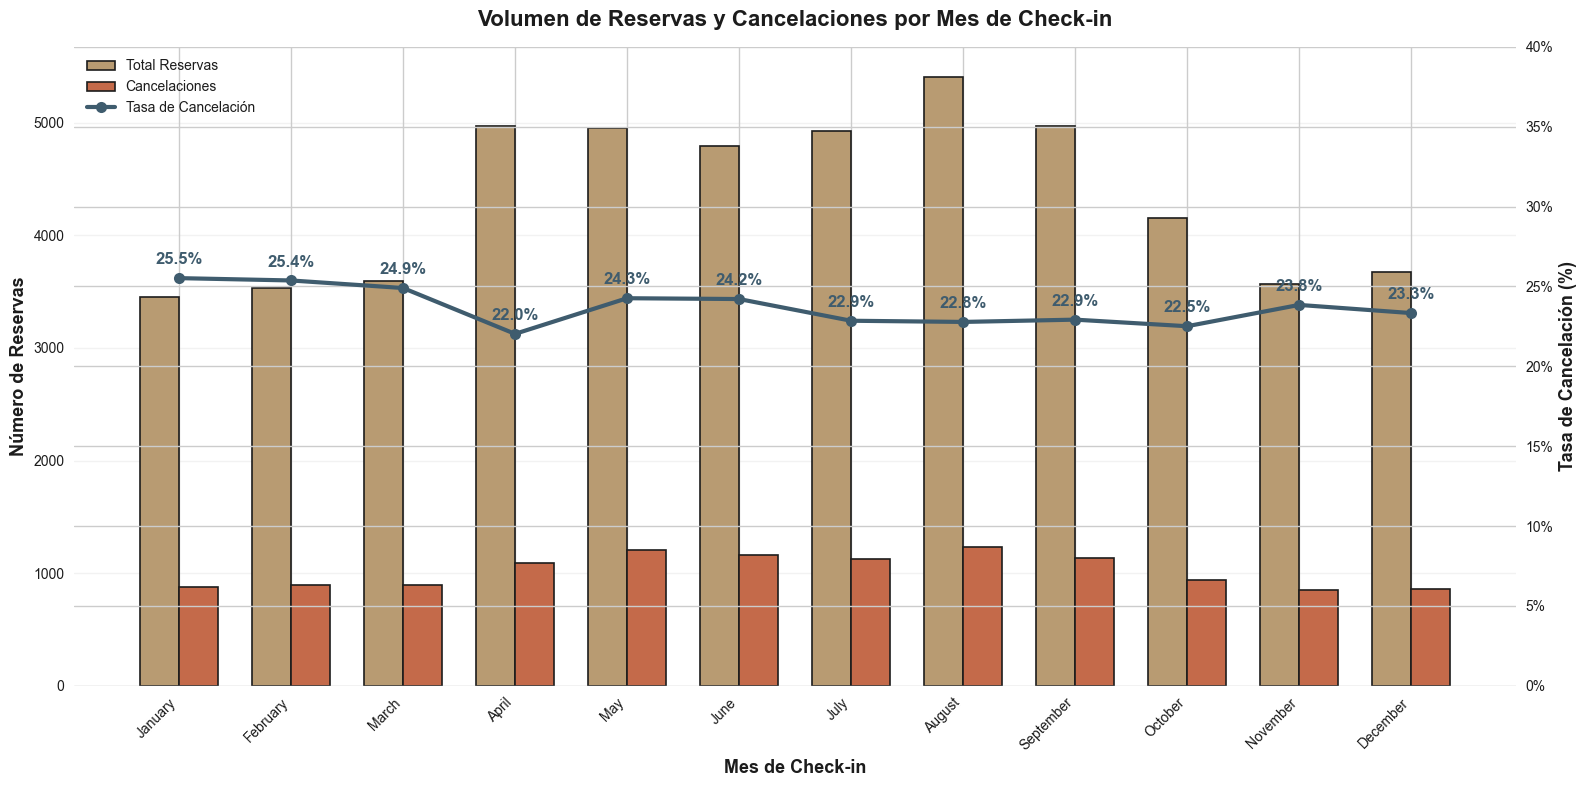

In [451]:
# GRÁFICO
fig, ax1 = plt.subplots(figsize=(16, 8))

x_pos = range(len(cancel_by_month))
width = 0.35

# Barras: total reservas
bars_total = ax1.bar(
    [p - width / 2 for p in x_pos],
    cancel_by_month['count'],
    width,
    label='Total Reservas',
    color=libere_true_graph_palette[2],  # Arena cálida
    edgecolor=libere_true_graph_palette[0],
    linewidth=1.2
)

# Barras: cancelaciones
bars_cancelled = ax1.bar(
    [p + width / 2 for p in x_pos],
    cancel_by_month['sum'],
    width,
    label='Cancelaciones',
    color=libere_true_graph_palette[5],  # Terracota
    edgecolor=libere_true_graph_palette[0],
    linewidth=1.2
)

ax1.set_xlabel('Mes de Check-in', fontsize=13, fontweight='bold')
ax1.set_ylabel('Número de Reservas', fontsize=13, fontweight='bold')
ax1.set_title(
    'Volumen de Reservas y Cancelaciones por Mes de Check-in',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(cancel_by_month.index, rotation=45, ha='right')

# EJE SECUNDARIO (TASA)
ax2 = ax1.twinx()

# Línea de tasa de cancelación
line = ax2.plot(
    x_pos,
    cancel_by_month['cancellation_rate'],
    marker='o',
    linewidth=3,
    color=libere_true_graph_palette[3],  # Azul acero
    label='Tasa de Cancelación',
    markersize=8
)

# ETIQUETAS PARA LA TASA DE CANCELACIÓN
for i, (x, y) in enumerate(zip(x_pos, cancel_by_month['cancellation_rate'])):
    ax2.annotate(
        f'{y:.1f}%',  # Formato con 1 decimal
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),  # Desplazamiento vertical de 10 puntos
        ha='center',
        fontsize=12,
        fontweight='bold',
        color=libere_true_graph_palette[3]  # Mismo color que la línea
    )

ax2.set_ylim(0, max(40, cancel_by_month['cancellation_rate'].max() * 1.2))
ax2.set_ylabel(
    'Tasa de Cancelación (%)',
    fontsize=13,
    fontweight='bold'
)

ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{int(x)}%')
)

ax2.tick_params(axis='y')

# LEYENDA Y GRID
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    frameon=False
)

ax1.grid(axis='y', alpha=0.25)

# FINAL
plt.tight_layout()
plt.show()

    TABLA RESUMEN: VOLUMEN DE RESERVAS Y CANCELACIONES POR MES

In [452]:
print("\n" + "="*80)
print("RESUMEN: VOLUMEN DE RESERVAS Y CANCELACIONES POR MES")
print("="*80)

# Crear tabla con información completa
summary_table = pd.DataFrame({
    'Total Reservas': cancel_by_month['count'].astype(int),
    'Cancelaciones': cancel_by_month['sum'].astype(int),
    'Completadas': (cancel_by_month['count'] - cancel_by_month['sum']).astype(int),
    'Tasa Cancelación (%)': cancel_by_month['cancellation_rate'].round(1),
    'Tasa Completadas (%)': (100 - cancel_by_month['cancellation_rate']).round(1)
})

print(summary_table.to_string())

print("\n" + "-"*80)
print("ANÁLISIS DESTACADO:")
print("-"*80)

# Calcular métricas clave
total_reservas = cancel_by_month['count'].sum()
total_cancelaciones = cancel_by_month['sum'].sum()
tasa_general = (total_cancelaciones / total_reservas) * 100

# Encontrar extremos
mes_max_reservas = cancel_by_month['count'].idxmax()
mes_min_reservas = cancel_by_month['count'].idxmin()
mes_max_cancel = cancel_by_month['sum'].idxmax()
mes_min_cancel = cancel_by_month['sum'].idxmin()
mes_max_tasa = cancel_by_month['cancellation_rate'].idxmax()
mes_min_tasa = cancel_by_month['cancellation_rate'].idxmin()

print(f"MES CON MÁS ACTIVIDAD:")
print(f"   • Reservas: {mes_max_reservas} ({cancel_by_month['count'].max():.0f} reservas)")
print(f"   • Cancelaciones: {mes_max_cancel} ({cancel_by_month['sum'].max():.0f} cancelaciones)")
print(f"   • Tasa más alta: {mes_max_tasa} ({cancel_by_month['cancellation_rate'].max():.1f}%)\n")

print(f"MES CON MENOS ACTIVIDAD:")
print(f"   • Reservas: {mes_min_reservas} ({cancel_by_month['count'].min():.0f} reservas)")
print(f"   • Cancelaciones: {mes_min_cancel} ({cancel_by_month['sum'].min():.0f} cancelaciones)")
print(f"   • Tasa más baja: {mes_min_tasa} ({cancel_by_month['cancellation_rate'].min():.1f}%)\n")

print("ESTADÍSTICAS GENERALES:")
print(f"   • Total reservas: {total_reservas:,}")
print(f"   • Total cancelaciones: {total_cancelaciones:,}")
print(f"   • Tasa general de cancelación: {tasa_general:.1f}%")
print(f"   • Tasa promedio mensual: {cancel_by_month['cancellation_rate'].mean():.1f}%")
print(f"   • Rango de tasas: {cancel_by_month['cancellation_rate'].min():.1f}% - {cancel_by_month['cancellation_rate'].max():.1f}%")
print(f"   • Meses analizados: {len(cancel_by_month)}")

# Calcular ratio cancelaciones/reservas por mes
print("\n RATIO CANCELACIONES/RESERVAS POR MES:")
print("-"*80)
for mes in cancel_by_month.index:
    total = int(cancel_by_month.loc[mes, 'count'])
    cancel = int(cancel_by_month.loc[mes, 'sum'])
    ratio = cancel / total if total > 0 else 0
    if cancel > 0:
        ratio_inv = 1/ratio if ratio > 0 else float('inf')
        print(f"   {mes}: {cancel}/{total} = {ratio:.2f} (1 cancelación cada {ratio_inv:.1f} reservas)")
    else:
        print(f"   {mes}: {cancel}/{total} = {ratio:.2f} (sin cancelaciones)")


RESUMEN: VOLUMEN DE RESERVAS Y CANCELACIONES POR MES
                    Total Reservas  Cancelaciones  Completadas  Tasa Cancelación (%)  Tasa Completadas (%)
checkin_month_name                                                                                        
January                       3452            881         2571                  25.5                  74.5
February                      3531            896         2635                  25.4                  74.6
March                         3598            896         2702                  24.9                  75.1
April                         4970           1095         3875                  22.0                  78.0
May                           4954           1202         3752                  24.3                  75.7
June                          4795           1161         3634                  24.2                  75.8
July                          4927           1126         3801                  22.9      

## Graficos Generales

    Tasa de Cancelación por Duración de Estancia 

C:\Users\unaip\AppData\Local\Temp\ipykernel_10372\1639796305.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df.groupby('stay_category').agg({


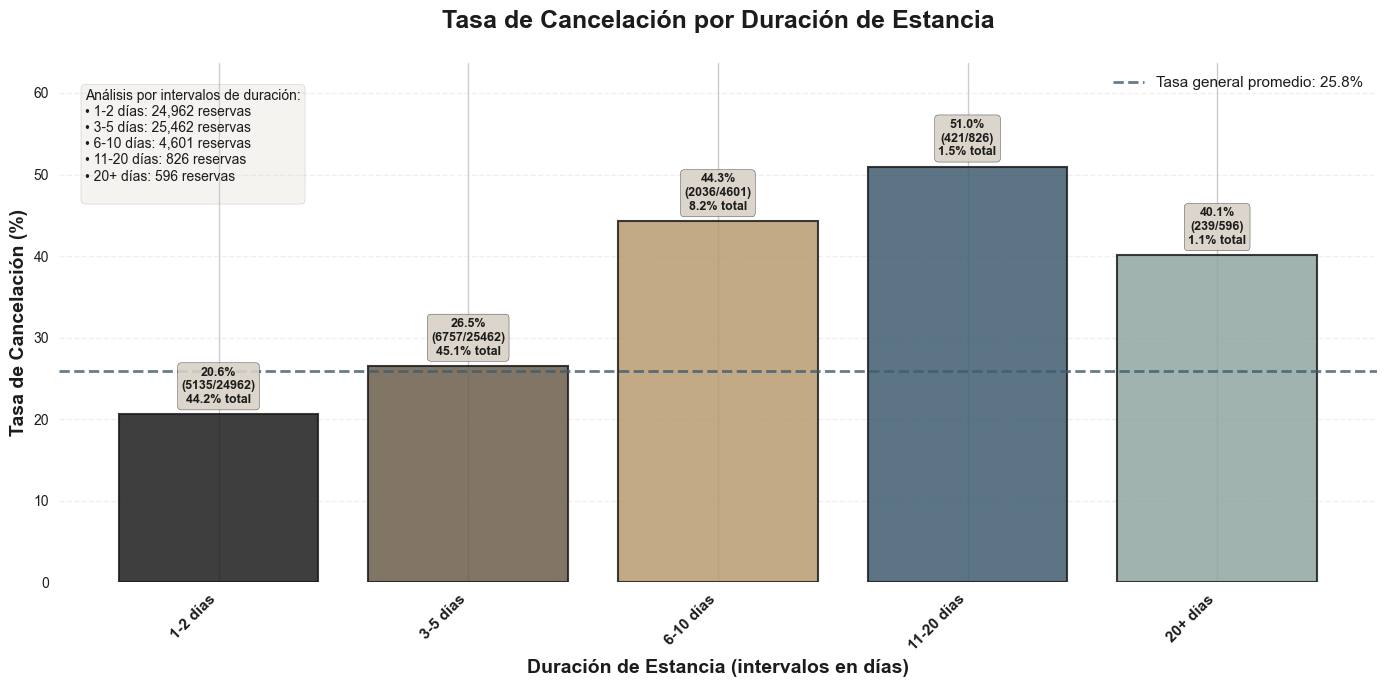

In [453]:
# Figura
plt.figure(figsize=(14, 7))

# Crear intervalos de duración
stay_limits = [0, 2, 5, 10, 20, df['lenght_of_stay'].max()]
labels = ['1-2 días', '3-5 días', '6-10 días', '11-20 días', '20+ días']

df['stay_category'] = pd.cut(
    df['lenght_of_stay'], 
    bins=stay_limits, 
    labels=labels, 
    include_lowest=True,
    right=False
)

# Estadísticas por categoría
category_stats = df.groupby('stay_category').agg({
    'is_cancelled': ['count', 'mean', 'sum']
}).reset_index()

category_stats.columns = ['category', 'total_reservations', 'cancellation_rate', 'cancelled_count']
category_stats['cancellation_rate_pct'] = category_stats['cancellation_rate'] * 100

# Barras
bars = plt.bar(
    range(len(category_stats)),
    category_stats['cancellation_rate_pct'],
    color=libere_true_graph_palette,  
    edgecolor=libere_true_graph_palette[0],
    linewidth=1.5,
    alpha=0.85
)

# Eje X
plt.xticks(
    range(len(category_stats)), 
    category_stats['category'],
    rotation=45, ha='right', fontweight='bold', fontsize=11
)

# Etiquetas detalladas
for i, row in category_stats.iterrows():
    height = row['cancellation_rate_pct']
    total_pct = (row['total_reservations'] / len(df)) * 100
    
    plt.text(
        i, 
        height + category_stats['cancellation_rate_pct'].max() * 0.02, 
        f'{height:.1f}%\n({int(row["cancelled_count"])}/{int(row["total_reservations"])})\n{total_pct:.1f}% total',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.3', 
            facecolor=libere_true_graph_palette[7],  # Gris claro
            alpha=0.9,
            edgecolor=libere_true_graph_palette[0]
        )
    )

# Línea promedio
overall_rate = df['is_cancelled'].mean() * 100
plt.axhline(
    y=overall_rate, 
    color=libere_true_graph_palette[3],  # Azul acero
    linestyle='--', 
    linewidth=2, 
    alpha=0.8, 
    label=f'Tasa general promedio: {overall_rate:.1f}%'
)

# Personalización
plt.title(
    'Tasa de Cancelación por Duración de Estancia', 
    fontsize=18, pad=25, fontweight='bold', color=libere_true_graph_palette[0]
)
plt.xlabel('Duración de Estancia (intervalos en días)', fontsize=14, fontweight='bold')
plt.ylabel('Tasa de Cancelación (%)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.ylim(0, category_stats['cancellation_rate_pct'].max() * 1.25)
plt.legend(loc='upper right', fontsize=11)

# Anotación explicativa
annotation_text = "Análisis por intervalos de duración:\n"
for _, row in category_stats.iterrows():
    annotation_text += f"• {row['category']}: {row['total_reservations']:,} reservas\n"

plt.text(
    0.02, 0.95, 
    annotation_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round', 
        facecolor=libere_true_graph_palette[7],  # Gris claro
        alpha=0.25,
        edgecolor=libere_true_graph_palette[0]
    )
)

plt.tight_layout()
plt.show()

    ANÁLISIS ESTADÍSTICO: DURACIÓN DE ESTANCIA vs CANCELACIÓN 

In [454]:
print("=" * 70)
print("ANÁLISIS ESTADÍSTICO: DURACIÓN DE ESTANCIA vs CANCELACIÓN")
print("=" * 70)

# Estadísticas generales
print(f"\n RESUMEN GENERAL:")
print(f"   {'Duración promedio (todas las reservas):':<45} {df['lenght_of_stay'].mean():.2f} días")
print(f"   {'Duración promedio (reservas canceladas):':<45} {df[df['is_cancelled']]['lenght_of_stay'].mean():.2f} días")
print(f"   {'Duración promedio (reservas no canceladas):':<45} {df[~df['is_cancelled']]['lenght_of_stay'].mean():.2f} días")
print(f"   {'Diferencia de duración (canceladas vs no canceladas):':<45} "
      f"{df[df['is_cancelled']]['lenght_of_stay'].mean() - df[~df['is_cancelled']]['lenght_of_stay'].mean():.2f} días")

print(f"\n DISTRIBUCIÓN POR INTERVALOS DE DURACIÓN:")
print("   " + "-" * 65)
print(f"   {'Duración':<12} {'Reservas':<10} {'% Total':<10} {'Canceladas':<12} {'Tasa %':<10} {'Dif. vs Prom.'}")
print("   " + "-" * 65)

overall_cancel_rate = df['is_cancelled'].mean() * 100

for idx, row in category_stats.iterrows():
    total_pct = (row['total_reservations'] / len(df)) * 100
    diff_vs_avg = row['cancellation_rate_pct'] - overall_cancel_rate
    diff_symbol = "+" if diff_vs_avg > 0 else ""
    
    print(f"   {row['category']:<12} {row['total_reservations']:<10,} {total_pct:<10.1f} "
          f"{int(row['cancelled_count']):<12,} {row['cancellation_rate_pct']:<10.1f} "
          f"{diff_symbol}{diff_vs_avg:>8.1f}%")

print("\n HALLAZGOS CLAVE:")
print("   " + "-" * 65)

# Hallazgo 1: Correlación
correlation = df['lenght_of_stay'].corr(df['is_cancelled'])
print(f"   1. CORRELACIÓN: La correlación entre duración y cancelación es {correlation:.3f}")
if correlation > 0.2:
    print(f"      → Existe una correlación POSITIVA FUERTE: a mayor duración, mayor probabilidad de cancelación.")
elif correlation > 0.1:
    print(f"      → Existe una correlación POSITIVA moderada: a mayor duración, mayor probabilidad de cancelación.")
elif correlation < -0.2:
    print(f"      → Existe una correlación NEGATIVA FUERTE: a mayor duración, menor probabilidad de cancelación.")
elif correlation < -0.1:
    print(f"      → Existe una correlación NEGATIVA moderada: a mayor duración, menor probabilidad de cancelación.")
else:
    print(f"      → La correlación es DÉBIL: la duración tiene poco efecto en la cancelación.")

# Hallazgo 2: Máximos y mínimos
max_rate_category = category_stats.loc[category_stats['cancellation_rate_pct'].idxmax()]
min_rate_category = category_stats.loc[category_stats['cancellation_rate_pct'].idxmin()]
print(f"\n   2. INTERVALOS EXTREMOS:")
print(f"      • MAYOR tasa de cancelación: {max_rate_category['category']} ({max_rate_category['cancellation_rate_pct']:.1f}%)")
print(f"      • MENOR tasa de cancelación: {min_rate_category['category']} ({min_rate_category['cancellation_rate_pct']:.1f}%)")

# Hallazgo 3: Impacto en el negocio
print(f"\n   3. IMPACTO EN EL NEGOCIO:")
total_cancelled = df['is_cancelled'].sum()
cancelled_in_max = max_rate_category['cancelled_count']
pct_of_total_cancelled = (cancelled_in_max / total_cancelled) * 100 if total_cancelled > 0 else 0
print(f"      • El intervalo {max_rate_category['category']} representa el {pct_of_total_cancelled:.1f}% de todas las cancelaciones")

# Hallazgo 4: Recomendaciones
print(f"\n   4. RECOMENDACIONES DE GESTIÓN:")
if max_rate_category['cancellation_rate_pct'] > overall_cancel_rate + 10:
    print(f"      ALERTA: Reservas de {max_rate_category['category']} tienen tasa {max_rate_category['cancellation_rate_pct'] - overall_cancel_rate:.1f}% sobre el promedio")
    print(f"      → Considerar: Depósitos no reembolsables, políticas más estrictas")
    
if min_rate_category['cancellation_rate_pct'] < overall_cancel_rate - 10:
    print(f"      OPORTUNIDAD: Reservas de {min_rate_category['category']} son más estables")
    print(f"      → Pueden ofrecerse: Tarifas más bajas, políticas flexibles")

print(f"\n   5. RESUMEN EJECUTIVO:")
if correlation > 0.1:
    print(f"      • Las reservas más largas tienden a cancelarse MÁS frecuentemente")
elif correlation < -0.1:
    print(f"      • Las reservas más largas tienden a cancelarse MENOS frecuentemente")
else:
    print(f"      • No hay relación clara entre duración y cancelación")

print("=" * 70)

ANÁLISIS ESTADÍSTICO: DURACIÓN DE ESTANCIA vs CANCELACIÓN

 RESUMEN GENERAL:
   Duración promedio (todas las reservas):       2.79 días
   Duración promedio (reservas canceladas):      3.39 días
   Duración promedio (reservas no canceladas):   2.58 días
   Diferencia de duración (canceladas vs no canceladas): 0.81 días

 DISTRIBUCIÓN POR INTERVALOS DE DURACIÓN:
   -----------------------------------------------------------------
   Duración     Reservas   % Total    Canceladas   Tasa %     Dif. vs Prom.
   -----------------------------------------------------------------
   1-2 días     24,962     44.2       5,135        20.6           -5.3%
   3-5 días     25,462     45.1       6,757        26.5       +     0.7%
   6-10 días    4,601      8.2        2,036        44.3       +    18.4%
   11-20 días   826        1.5        421          51.0       +    25.1%
   20+ días     596        1.1        239          40.1       +    14.3%

 HALLAZGOS CLAVE:
   ------------------------------------

# GRÁFICOS DE CANCELACIÓN 

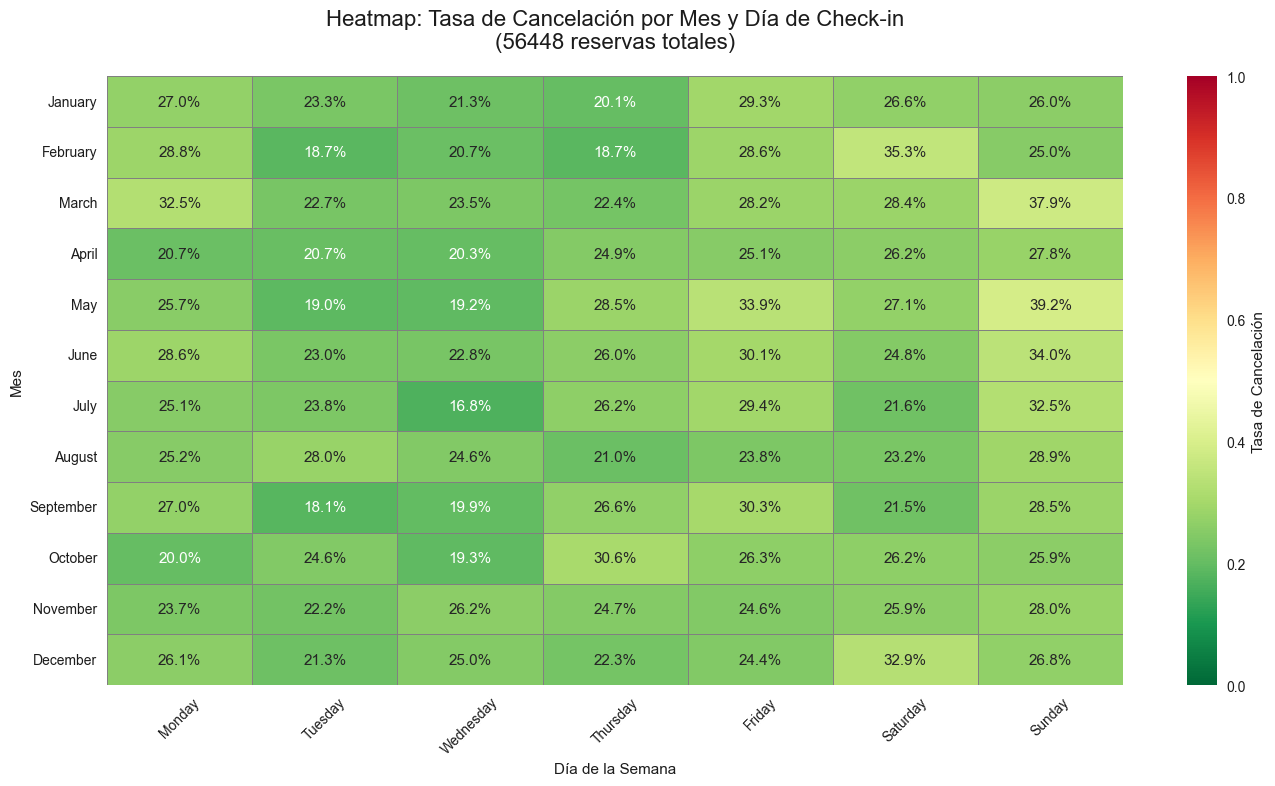

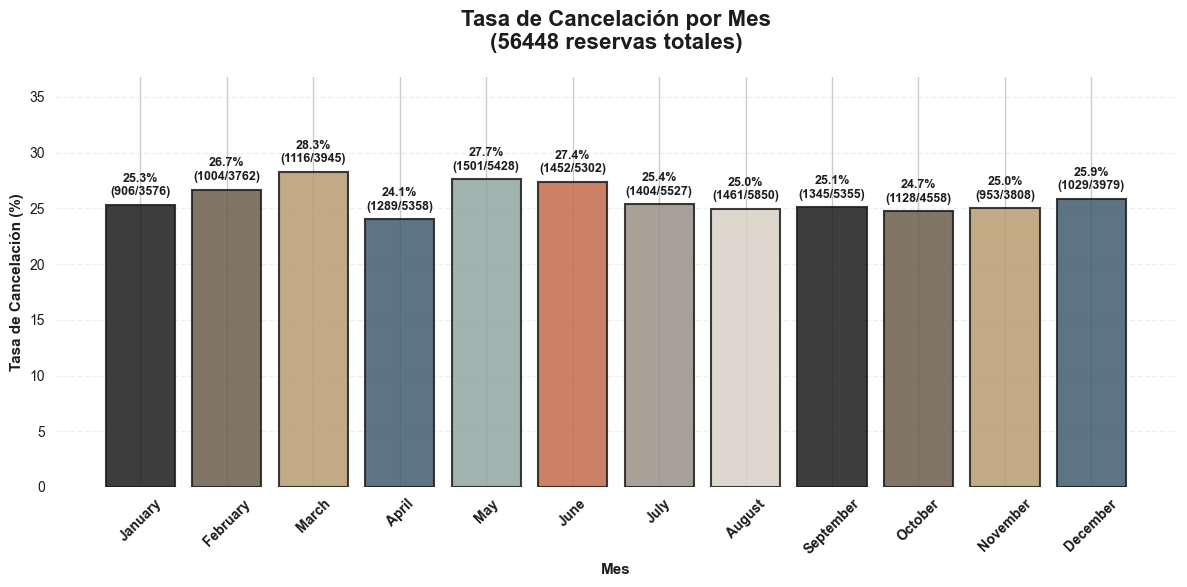

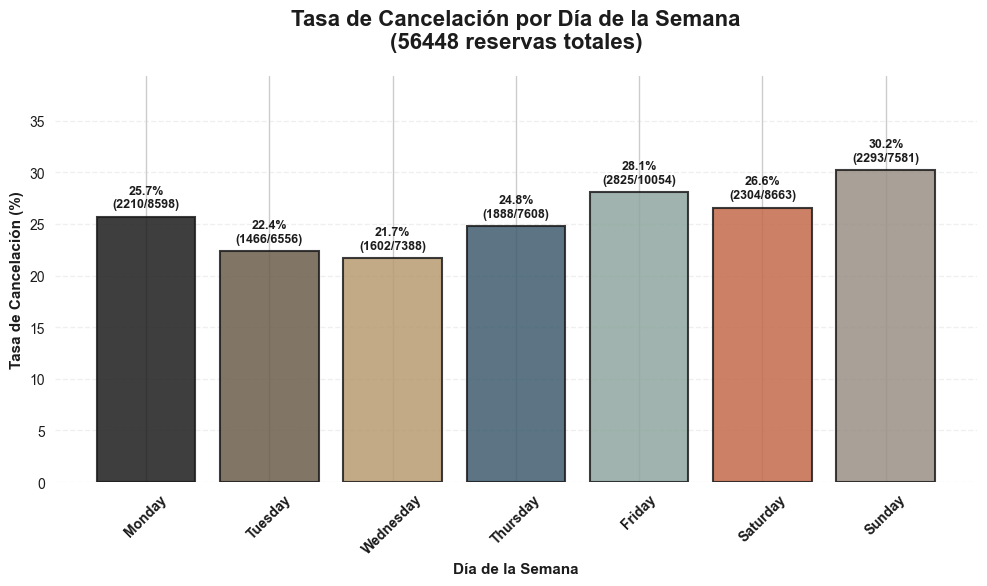

In [455]:
# 0. DIAGNÓSTICO Y NORMALIZACIÓN
df['checkin_month'] = df['checkin_month'].astype(str).str.strip()
df['checkin_day'] = df['checkin_day'].astype(str).str.strip()

if 'is_cancelled' not in df.columns:
    if 'status' in df.columns:
        df['is_cancelled'] = df['status'].str.lower().eq('cancelled')
    else:
        print("Advertencia: No se encontró columna 'status'. Creando columna dummy is_cancelled.")
        df['is_cancelled'] = False

# Normalización de meses
month_variations = {
    'January': ['january','jan','1','01','enero'],
    'February': ['february','feb','2','02','febrero'],
    'March': ['march','mar','3','03','marzo'],
    'April': ['april','apr','4','04','abril'],
    'May': ['may','5','05','mayo'],
    'June': ['june','jun','6','06','junio'],
    'July': ['july','jul','7','07','julio'],
    'August': ['august','aug','8','08','agosto'],
    'September': ['september','sep','9','09','septiembre'],
    'October': ['october','oct','10','octubre'],
    'November': ['november','nov','11','noviembre'],
    'December': ['december','dec','12','diciembre']
}

month_normalization = {var.lower():std for std, vars in month_variations.items() for var in vars}
unique_months = df['checkin_month'].unique()
if any(m.lower() in month_normalization for m in unique_months):
    df['checkin_month_normalized'] = df['checkin_month'].str.lower().map(month_normalization).fillna(df['checkin_month'])
    month_col = 'checkin_month_normalized'
else:
    month_col = 'checkin_month'

# Normalización de días
day_variations = {
    'Monday': ['monday','mon','lunes','1'],
    'Tuesday': ['tuesday','tue','tues','martes','2'],
    'Wednesday': ['wednesday','wed','miercoles','miércoles','3'],
    'Thursday': ['thursday','thu','thurs','jueves','4'],
    'Friday': ['friday','fri','viernes','5'],
    'Saturday': ['saturday','sat','sabado','sábado','6'],
    'Sunday': ['sunday','sun','domingo','7']
}

day_normalization = {var.lower():std for std, vars in day_variations.items() for var in vars}
unique_days = df['checkin_day'].unique()
if any(d.lower() in day_normalization for d in unique_days):
    df['checkin_day_normalized'] = df['checkin_day'].str.lower().map(day_normalization).fillna(df['checkin_day'])
    day_col = 'checkin_day_normalized'
else:
    day_col = 'checkin_day'

# Orden de meses y días presentes
month_order_data = [m for m in ['January','February','March','April','May','June',
                                'July','August','September','October','November','December'] 
                    if m in df[month_col].unique()]
day_order_data = [d for d in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
                  if d in df[day_col].unique()]

# 1. HEATMAP – TASA DE CANCELACIÓN POR MES Y DÍA (CORREGIDO)
if len(month_order_data) > 0 and len(day_order_data) > 0:
    plt.figure(figsize=(14, 8))

    heatmap_data = (
        df.groupby([month_col, day_col])['is_cancelled']
        .agg(['mean', 'count'])
        .reset_index()
    )
    
    # Renombrar columnas para claridad
    heatmap_data.columns = [month_col, day_col, 'cancellation_rate', 'count']
    
    
    if not heatmap_data.empty:
        heatmap_pivot = heatmap_data.pivot(
            index=month_col,
            columns=day_col,
            values='cancellation_rate'
        )
        
        
        # Reordenar según los datos disponibles
        available_months = [m for m in month_order_data if m in heatmap_pivot.index]
        available_days = [d for d in day_order_data if d in heatmap_pivot.columns]
        
        if available_months and available_days:
            heatmap_pivot = heatmap_pivot.reindex(index=available_months, columns=available_days)
            
            # Rellenar NaN con 0 para visualización
            heatmap_pivot_filled = heatmap_pivot.fillna(0)
            
            sns.heatmap(
                heatmap_pivot_filled,
                annot=True,
                fmt='.1%',
                cmap='RdYlGn_r',
                linewidths=0.5,
                linecolor='gray',
                cbar_kws={'label': 'Tasa de Cancelación'},
                vmin=0,
                vmax=1,
                center=0.5,
                mask=heatmap_pivot.isnull()  # Enmascarar celdas sin datos reales
            )
            
            plt.title(f'Heatmap: Tasa de Cancelación por Mes y Día de Check-in\n({len(df)} reservas totales)', 
                     fontsize=16, pad=20)
            plt.xlabel('Día de la Semana')
            plt.ylabel('Mes')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"Advertencia: No hay coincidencias entre los datos y el orden esperado.")
            print(f"Meses disponibles en heatmap: {heatmap_pivot.index.tolist()}")
            print(f"Días disponibles en heatmap: {heatmap_pivot.columns.tolist()}")
    else:
        print("Advertencia: No hay datos suficientes para generar el heatmap.")
else:
    print(f"Advertencia: No hay datos de meses ({len(month_order_data)}) o días ({len(day_order_data)}).")  

# 2. GRÁFICO DE BARRAS – TASA DE CANCELACIÓN POR MES
if month_order_data:
    cancellation_by_month = df.groupby(month_col).agg(
        total_reservations=('is_cancelled','count'),
        cancelled_reservations=('is_cancelled','sum')
    ).reset_index()
    cancellation_by_month['cancellation_rate'] = cancellation_by_month['cancelled_reservations']/cancellation_by_month['total_reservations']*100
    cancellation_by_month[month_col] = pd.Categorical(cancellation_by_month[month_col], categories=month_order_data, ordered=True)
    cancellation_by_month = cancellation_by_month.sort_values(month_col)
    
    if not cancellation_by_month.empty:
        plt.figure(figsize=(12,6))
        bars = plt.bar(
            cancellation_by_month[month_col].astype(str),
            cancellation_by_month['cancellation_rate'],
            color=libere_true_graph_palette,  # Terracota
            edgecolor=libere_true_graph_palette[0],
            linewidth=1.5,
            alpha=0.85
        )
        ymax_month = cancellation_by_month['cancellation_rate'].max()
        for bar, row in zip(bars, cancellation_by_month.itertuples()):
            plt.text(
                bar.get_x()+bar.get_width()/2,
                row.cancellation_rate + ymax_month*0.02,
                f"{row.cancellation_rate:.1f}%\n({int(row.cancelled_reservations)}/{int(row.total_reservations)})",
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )
        plt.ylim(0, ymax_month*1.3 if ymax_month>0 else 100)
        plt.title(f'Tasa de Cancelación por Mes\n({len(df)} reservas totales)', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Mes', fontweight='bold')
        plt.ylabel('Tasa de Cancelación (%)', fontweight='bold')
        plt.xticks(rotation=45, fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

# 3. GRÁFICO DE BARRAS – TASA DE CANCELACIÓN POR DÍA
if day_order_data:
    cancellation_by_day = df.groupby(day_col).agg(
        total_reservations=('is_cancelled','count'),
        cancelled_reservations=('is_cancelled','sum')
    ).reset_index()
    cancellation_by_day['cancellation_rate'] = cancellation_by_day['cancelled_reservations']/cancellation_by_day['total_reservations']*100
    cancellation_by_day[day_col] = pd.Categorical(cancellation_by_day[day_col], categories=day_order_data, ordered=True)
    cancellation_by_day = cancellation_by_day.sort_values(day_col)
    
    if not cancellation_by_day.empty and cancellation_by_day['cancellation_rate'].notna().any():
        plt.figure(figsize=(10,6))
        bars = plt.bar(
            cancellation_by_day[day_col].astype(str),
            cancellation_by_day['cancellation_rate'],
            color=libere_true_graph_palette,  # Terracota
            edgecolor=libere_true_graph_palette[0],
            linewidth=1.5,
            alpha=0.85
        )
        valid_rates = cancellation_by_day['cancellation_rate'].dropna()
        ymax_day = valid_rates.max() if not valid_rates.empty else 10
        for bar, row in zip(bars, cancellation_by_day.itertuples()):
            plt.text(
                bar.get_x()+bar.get_width()/2,
                row.cancellation_rate + ymax_day*0.02,
                f"{row.cancellation_rate:.1f}%\n({int(row.cancelled_reservations)}/{int(row.total_reservations)})",
                ha='center', va='bottom', fontsize=9, fontweight='bold'
            )
        plt.ylim(0, ymax_day*1.3 if ymax_day>0 else 100)
        plt.title(f'Tasa de Cancelación por Día de la Semana\n({len(df)} reservas totales)', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Día de la Semana', fontweight='bold')
        plt.ylabel('Tasa de Cancelación (%)', fontweight='bold')
        plt.xticks(rotation=45, fontweight='bold')
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

    Distribucion dias de anticipacion

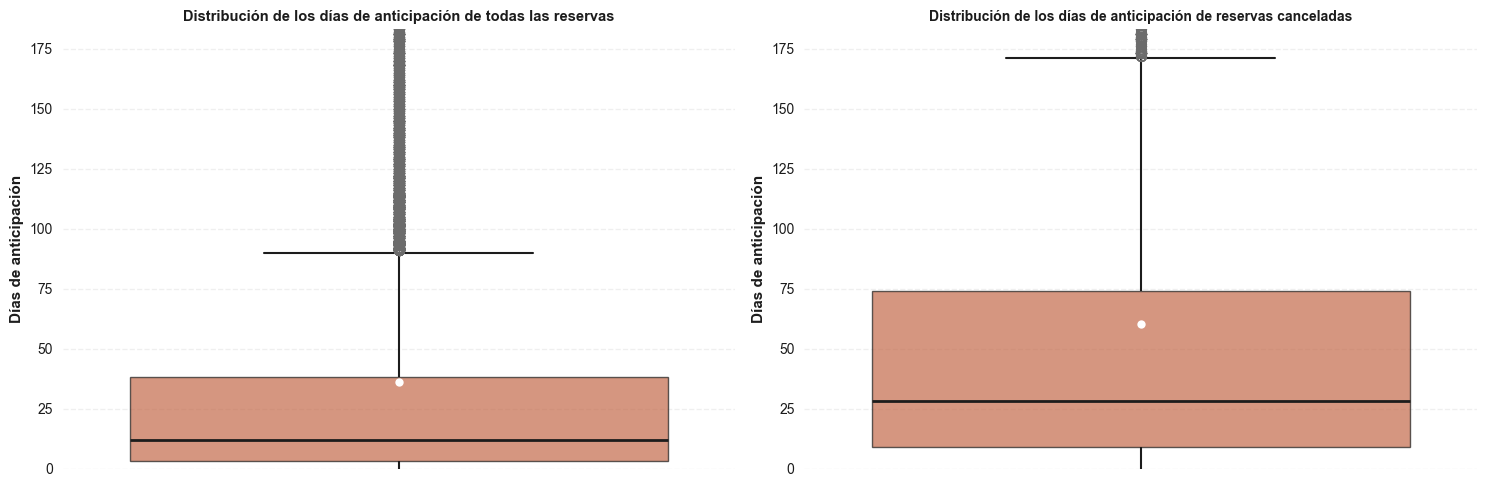

In [456]:
# Filtrar cancelaciones
df_cancelaciones = df[df['status'] == 'cancelled']

# Crear figura con 2 boxplots
fig8, ax8 = plt.subplots(1, 2, figsize=(15, 5))

# 1. Boxplot: Todas las reservas
b1 = sns.boxplot(
    y='lead_time',
    data=df,
    boxprops=dict(facecolor=libere_true_graph_palette[5], alpha=0.7, edgecolor=libere_true_graph_palette[0]),
    whiskerprops=dict(color=libere_true_graph_palette[0], linewidth=1.5),
    capprops=dict(color=libere_true_graph_palette[0], linewidth=1.5),
    medianprops=dict(color=libere_true_graph_palette[0], linewidth=2),
    meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black'),
    showmeans=True,
    showfliers=True,
    ax=ax8[0]
)

ax8[0].grid(alpha=0.3, linestyle='--', axis='y')
ax8[0].set_ylim(0, 183)
ax8[0].set_ylabel('Días de anticipación', fontweight='bold', color=libere_true_graph_palette[0])
ax8[0].set_xlabel('')
ax8[0].set_xticks([])
ax8[0].set_title(
    'Distribución de los días de anticipación de todas las reservas',
    fontsize=10.5,
    fontweight='bold',
    color=libere_true_graph_palette[0]
)

# 2. Boxplot: Solo cancelaciones
b2 = sns.boxplot(
    y='lead_time',
    data=df_cancelaciones,
    boxprops=dict(facecolor=libere_true_graph_palette[5], alpha=0.7, edgecolor=libere_true_graph_palette[0]),
    whiskerprops=dict(color=libere_true_graph_palette[0], linewidth=1.5),
    capprops=dict(color=libere_true_graph_palette[0], linewidth=1.5),
    medianprops=dict(color=libere_true_graph_palette[0], linewidth=2),
    meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black'),
    showmeans=True,
    showfliers=True,
    ax=ax8[1]
)

ax8[1].grid(alpha=0.3, linestyle='--', axis='y')
ax8[1].set_ylim(0, 183)
ax8[1].set_ylabel('Días de anticipación', fontweight='bold', color=libere_true_graph_palette[0])
ax8[1].set_xlabel('')
ax8[1].set_xticks([])
ax8[1].set_title(
    'Distribución de los días de anticipación de reservas canceladas',
    fontsize=10,
    fontweight='bold',
    color=libere_true_graph_palette[0]
)

plt.tight_layout()
plt.show()

    RESUMEN ESTADÍSTICO DE CANCELACIONES

In [457]:
print("=" * 60)
print("RESUMEN ESTADÍSTICO DE CANCELACIONES")
print("=" * 60)

total_reservations = len(df)
total_cancelled = df['is_cancelled'].sum()
overall_rate = (total_cancelled / total_reservations) * 100 if total_reservations > 0 else 0

print(f"Total de reservas: {total_reservations}")
print(f"Total de cancelaciones: {total_cancelled}")
print(f"Tasa general de cancelación: {overall_rate:.2f}%")

print(f"\nTasa de cancelación por mes:")
if not cancellation_by_month.empty:
    for _, row in cancellation_by_month.iterrows():
        month_name = row[month_col]
        r = row['cancellation_rate']
        t = row['total_reservations']
        c = row['cancelled_reservations']
        if not np.isnan(r):
            print(f"  {str(month_name):12s}: {r:5.1f}% ({int(c):3d}/{int(t):3d})")
        else:
            print(f"  {str(month_name):12s}: Sin datos")
else:
    print("  No hay datos de meses")

print(f"\nTasa de cancelación por día:")
if not cancellation_by_day.empty:
    for _, row in cancellation_by_day.iterrows():
        day_name = row[day_col]
        r = row['cancellation_rate']
        t = row['total_reservations']
        c = row['cancelled_reservations']
        if not np.isnan(r):
            print(f"  {str(day_name):12s}: {r:5.1f}% ({int(c):3d}/{int(t):3d})")
        else:
            print(f"  {str(day_name):12s}: Sin datos")
else:
    print("  No hay datos de días")

print("=" * 60)

RESUMEN ESTADÍSTICO DE CANCELACIONES
Total de reservas: 56448
Total de cancelaciones: 14588
Tasa general de cancelación: 25.84%

Tasa de cancelación por mes:
  January     :  25.3% (906/3576)
  February    :  26.7% (1004/3762)
  March       :  28.3% (1116/3945)
  April       :  24.1% (1289/5358)
  May         :  27.7% (1501/5428)
  June        :  27.4% (1452/5302)
  July        :  25.4% (1404/5527)
  August      :  25.0% (1461/5850)
  September   :  25.1% (1345/5355)
  October     :  24.7% (1128/4558)
  November    :  25.0% (953/3808)
  December    :  25.9% (1029/3979)

Tasa de cancelación por día:
  Monday      :  25.7% (2210/8598)
  Tuesday     :  22.4% (1466/6556)
  Wednesday   :  21.7% (1602/7388)
  Thursday    :  24.8% (1888/7608)
  Friday      :  28.1% (2825/10054)
  Saturday    :  26.6% (2304/8663)
  Sunday      :  30.2% (2293/7581)


## Graficos General

    Dias de Anticipacion

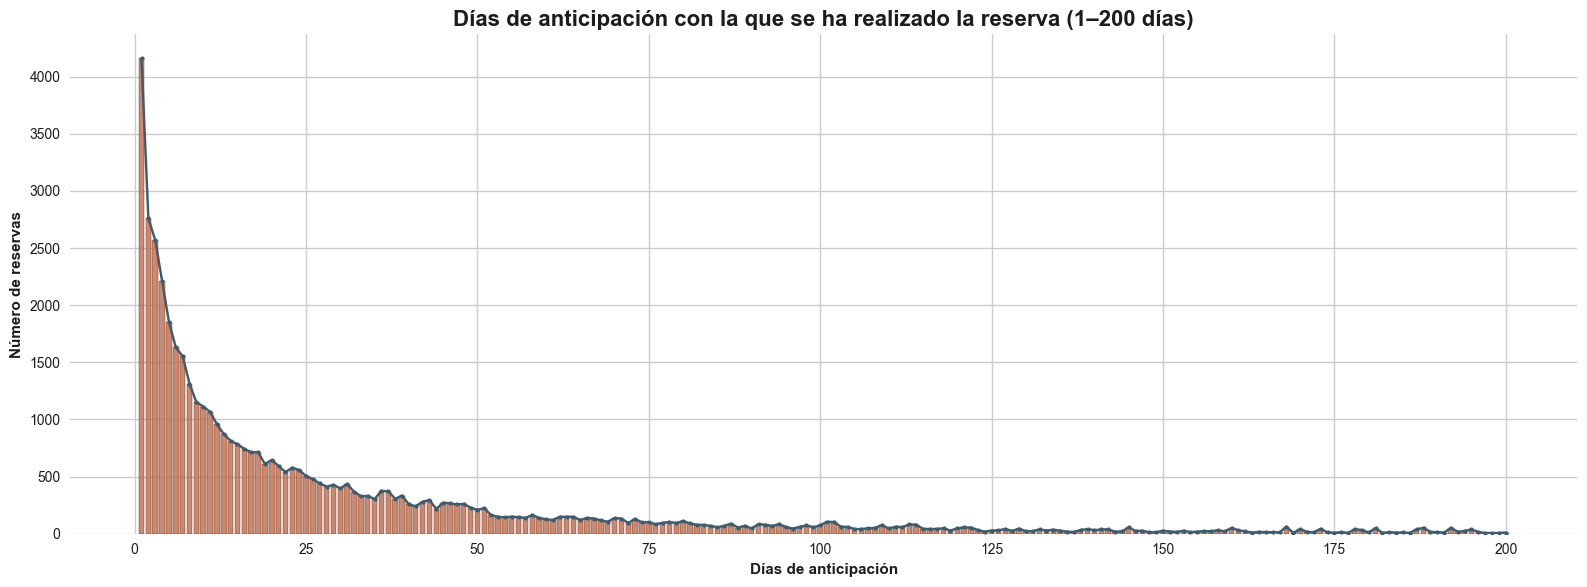

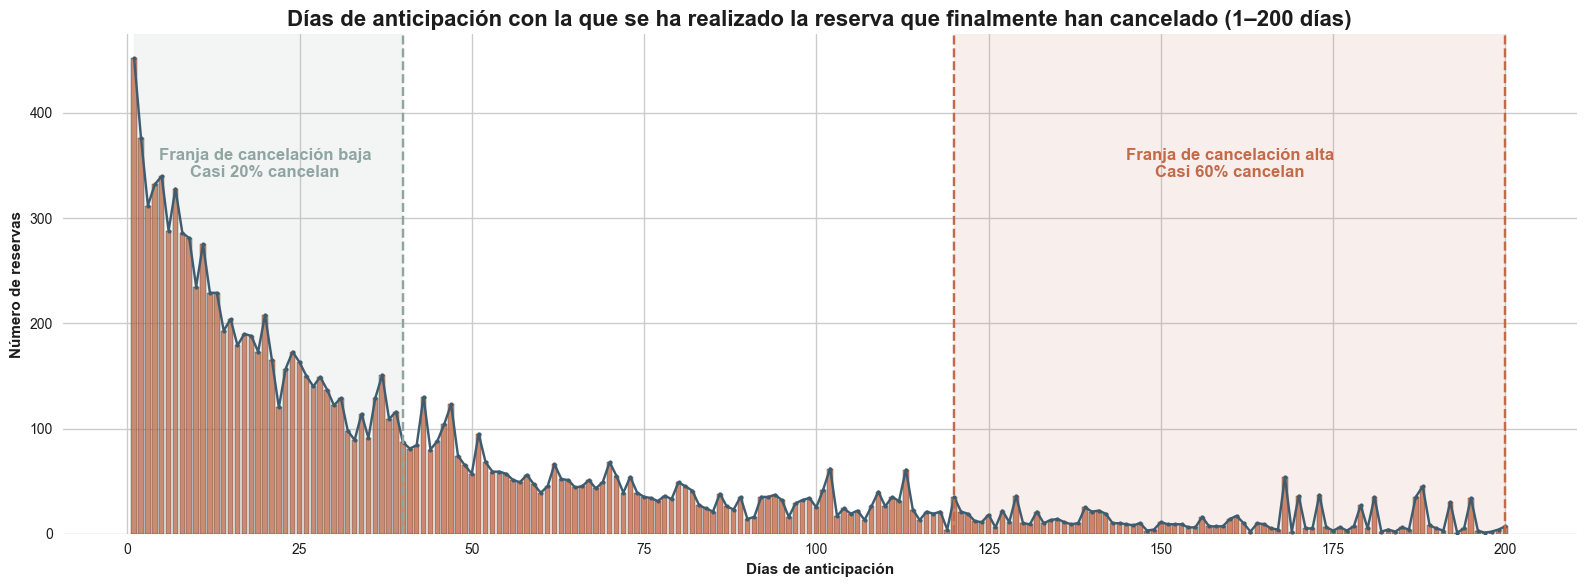

In [458]:
# FILTRO: solo de 1 a 200 días
df = df[(df["lead_time"] > 0) & (df["lead_time"] <= 200)]
df = df.sort_values("lead_time")

# Contar reservas por día
reservas = df.groupby("lead_time").size()

# Contar cancelaciones por día
cancelaciones = df[df["is_cancelled"] == 1].groupby("lead_time").size()
cancelaciones = cancelaciones.reindex(reservas.index, fill_value=0)

# FIGURA 1 — Todas las reservas por días de anticipación
fig, ax = plt.subplots(figsize=(16,6))

ax.bar(reservas.index, reservas.values, color=libere_true_graph_palette[5], alpha=0.8, edgecolor=libere_true_graph_palette[0])
ax.plot(reservas.index, reservas.values, color=libere_true_graph_palette[3], marker="o", markersize=3)

ax.set_title("Días de anticipación con la que se ha realizado la reserva (1–200 días)", fontsize=16, fontweight='bold')
ax.set_xlabel("Días de anticipación", fontweight='bold')
ax.set_ylabel("Número de reservas", fontweight='bold')

plt.tight_layout()
plt.show()

# FIGURA 2 — Cancelaciones por días de anticipación
fig, ax = plt.subplots(figsize=(16,6))

ax.bar(cancelaciones.index, cancelaciones.values, color=libere_true_graph_palette[5], alpha=0.8, edgecolor=libere_true_graph_palette[0])
ax.plot(cancelaciones.index, cancelaciones.values, color=libere_true_graph_palette[3], marker="o", markersize=3)

ax.set_title("Días de anticipación con la que se ha realizado la reserva que finalmente han cancelado (1–200 días)", fontsize=16, fontweight='bold')
ax.set_xlabel("Días de anticipación", fontweight='bold')
ax.set_ylabel("Número de reservas", fontweight='bold')

# Franjas de cancelación
# Franja alta: 120–200 días
ax.axvspan(120, 200, color=libere_true_graph_palette[5], alpha=0.1)
ax.axvline(120, color=libere_true_graph_palette[5], linestyle="--")
ax.axvline(200, color=libere_true_graph_palette[5], linestyle="--")
ax.text(160, max(cancelaciones)*0.75,
        "Franja de cancelación alta\nCasi 60% cancelan",
        color=libere_true_graph_palette[5], fontsize=12, ha="center", fontweight='bold')

# Franja baja: 1–40 días
ax.axvspan(1, 40, color=libere_true_graph_palette[4], alpha=0.1)
ax.axvline(40, color=libere_true_graph_palette[4], linestyle="--")
ax.text(20, max(cancelaciones)*0.75,
        "Franja de cancelación baja\nCasi 20% cancelan",
        color=libere_true_graph_palette[4], fontsize=12, ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

    Razon de reserva VS Tipo de Habitacion


Tabla de contingencia - Tipos de habitación por segmento de negocio:
requested_category   Hostel bed  Hostel room  One bedroom apartment  \
business_segment                                                      
Business Group                0            7                      6   
Business Individual          15          139                    171   
Leisure Group                 3           69                     31   
Leisure Individual         1395         2425                   2200   
MICE Group                    0           66                     82   
MICE Individual              12            1                      7   
Mid Stay                      0            2                     19   
Travel Group                  0          113                     39   
Travel Individual            16          148                    258   

requested_category   One bedroom apartment superior  Studio  Studio superior  \
business_segment                                                    

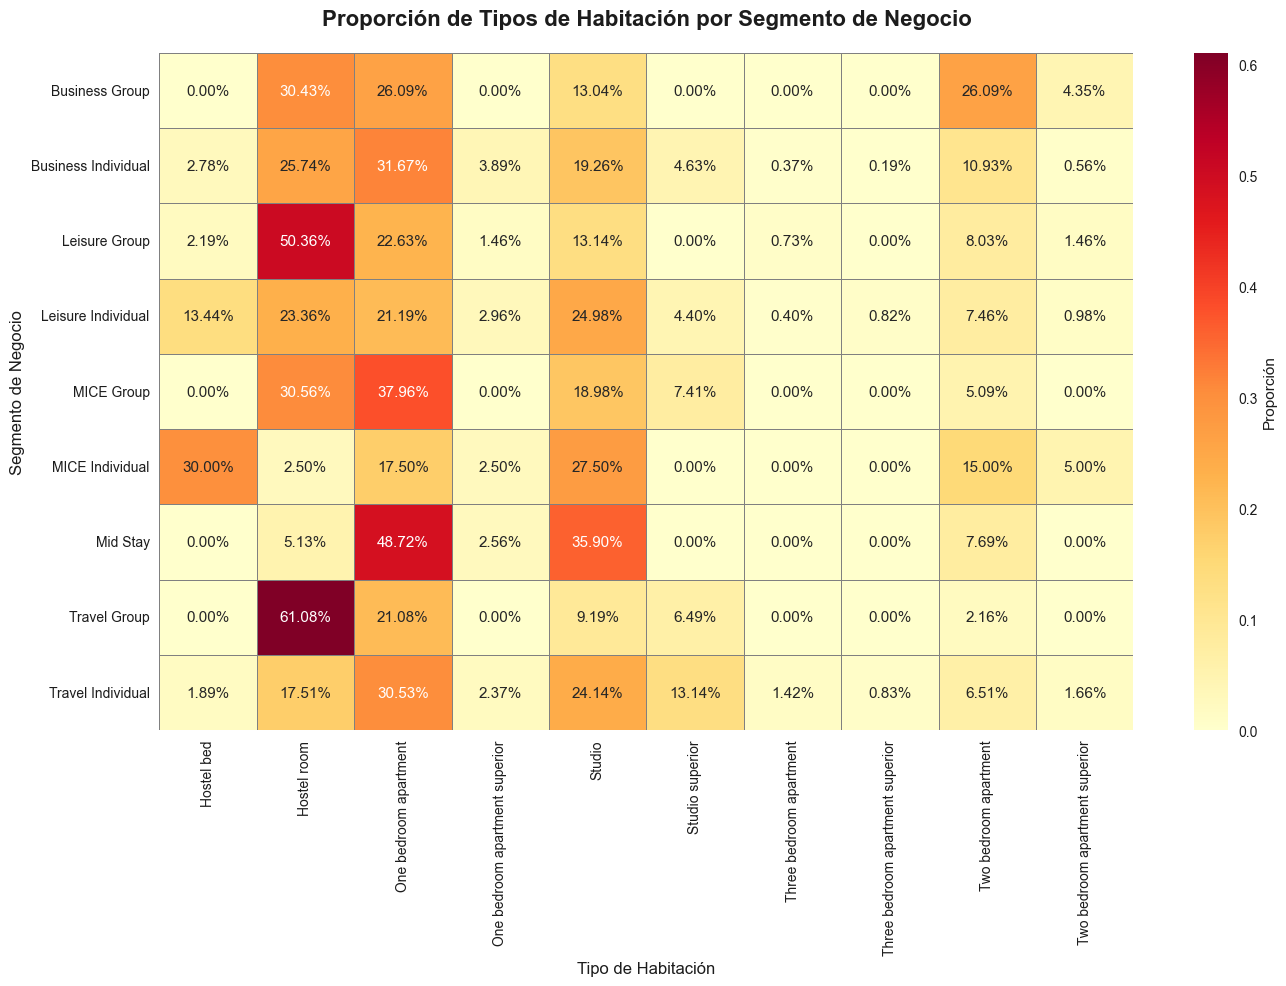


DISTRIBUCIÓN DE SEGMENTOS DE NEGOCIO:
Leisure Individual: 10,380 cancelaciones (83.7%)
Travel Individual: 845 cancelaciones (6.8%)
Business Individual: 540 cancelaciones (4.4%)
MICE Group: 216 cancelaciones (1.7%)
Travel Group: 185 cancelaciones (1.5%)
Leisure Group: 137 cancelaciones (1.1%)
MICE Individual: 40 cancelaciones (0.3%)
Mid Stay: 39 cancelaciones (0.3%)
Business Group: 23 cancelaciones (0.2%)

DISTRIBUCIÓN DE TIPOS DE HABITACIÓN:
Studio: 3,005 cancelaciones (24.2%)
Hostel room: 2,970 cancelaciones (23.9%)
One bedroom apartment: 2,813 cancelaciones (22.7%)
Hostel bed: 1,441 cancelaciones (11.6%)
Two bedroom apartment: 929 cancelaciones (7.5%)
Studio superior: 621 cancelaciones (5.0%)
One bedroom apartment superior: 352 cancelaciones (2.8%)
Two bedroom apartment superior: 124 cancelaciones (1.0%)
Three bedroom apartment superior: 93 cancelaciones (0.7%)
Three bedroom apartment: 57 cancelaciones (0.5%)

ANÁLISIS CRUZADO DETALLADO:

Segmento: Business Group
-------------------

In [459]:
# Filtrar solo las cancelaciones
cancelled_df = df[df['status'] == 'cancelled'].copy()

# Limpiar valores nulos en las columnas de interés
cancelled_df = cancelled_df.dropna(subset=['business_segment', 'requested_category'])

# Opcional: Crear una tabla de contingencia para ver los números exactos
contingency_table = pd.crosstab(cancelled_df['business_segment'], 
                                cancelled_df['requested_category'])
print("\nTabla de contingencia - Tipos de habitación por segmento de negocio:")
print(contingency_table)

# Calcular proporciones por fila (normalizado por segmento de negocio)
contingency_table_normalized = contingency_table.div(contingency_table.sum(axis=1), axis=0)

# Crear heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(contingency_table_normalized, 
            annot=True, 
            fmt='.2%', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Proporción'},
            linewidths=0.5,
            linecolor='gray')

plt.title('Proporción de Tipos de Habitación por Segmento de Negocio', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12)
plt.ylabel('Segmento de Negocio', fontsize=12)

plt.tight_layout()
plt.show()

# Análisis adicional por segmento de negocio
print("\n" + "="*80)
print("DISTRIBUCIÓN DE SEGMENTOS DE NEGOCIO:")
print("="*80)
segment_distribution = cancelled_df['business_segment'].value_counts()
for segment, count in segment_distribution.items():
    percentage = (count / len(cancelled_df)) * 100
    print(f"{segment}: {count:,} cancelaciones ({percentage:.1f}%)")

print("\n" + "="*80)
print("DISTRIBUCIÓN DE TIPOS DE HABITACIÓN:")
print("="*80)
category_distribution = cancelled_df['requested_category'].value_counts()
for category, count in category_distribution.items():
    percentage = (count / len(cancelled_df)) * 100
    print(f"{category}: {count:,} cancelaciones ({percentage:.1f}%)")
print("="*80)

# Análisis cruzado detallado
print("\n" + "="*80)
print("ANÁLISIS CRUZADO DETALLADO:")
print("="*80)
for segment in contingency_table.index:
    print(f"\nSegmento: {segment}")
    print("-" * 40)
    segment_total = contingency_table.loc[segment].sum()
    for category in contingency_table.columns:
        count = contingency_table.loc[segment, category]
        if count > 0:
            percentage = (count / segment_total) * 100
            print(f"  {category}: {count:,} ({percentage:.1f}%)")
print("="*80)

#### Reservas y cancelaciones Por Ciudades

In [464]:
conversion = {
    "Líbere Vitoria": "Vitoria",
    "Líbere Córdoba Patio Santa Marta": "Córdoba",
    "Koisi Hostel": "Donosti",
    "Líbere Madrid Palacio Real": "Madrid",
    "Líbere Pamplona Yamaguchi": "Pamplona",
    "Líbere Málaga Teatro Romano": "Málaga",
    "Líbere Valencia Jardín Botánico": "Valencia",
    "Líbere Valencia Abastos": "Valencia",
    "Líbere Granada Catedral": "Granada",
    "Líbere Bilbao La Vieja": "Bilbao",
    "Líbere Bilbao Museo": "Bilbao",
    "Líbere Málaga la Merced": "Málaga"
}

# Load datos
path_datos = os.path.join('Datos','Transformados')
filename = os.path.join(path_datos,'df_limpio.csv')
df = pd.read_csv(filename)
df['is_cancelled'] = df['status'] == 'cancelled'
# Crear nueva columna 'ciudad'
df['ciudad'] = df['asset'].map(conversion)

# Mostrar primeros registros para verificar
print(df[['asset', 'ciudad']].head())

          asset   ciudad
0  Koisi Hostel  Donosti
1  Koisi Hostel  Donosti
2  Koisi Hostel  Donosti
3  Koisi Hostel  Donosti
4  Koisi Hostel  Donosti


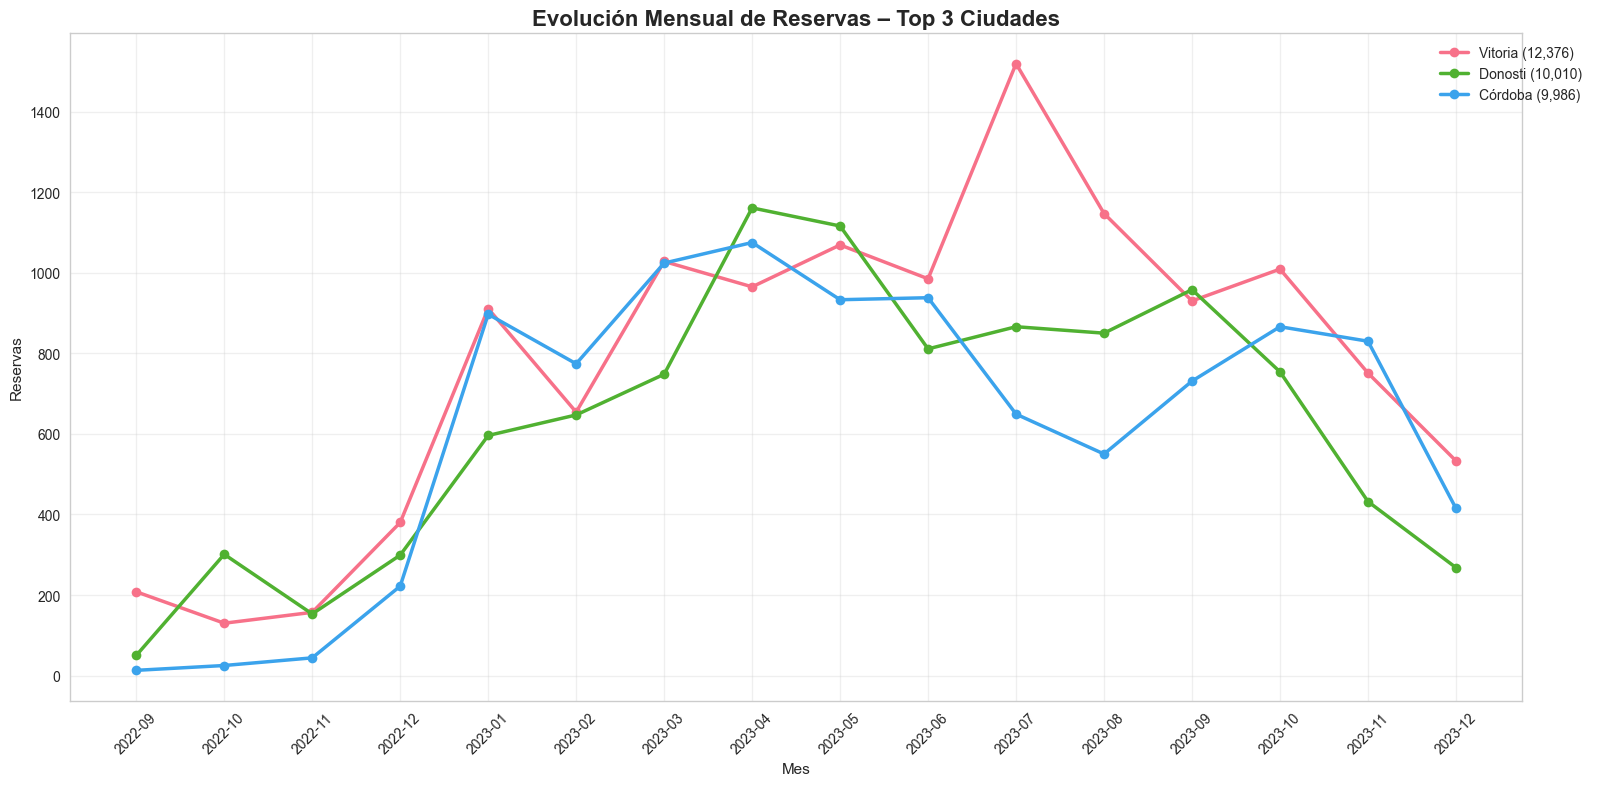

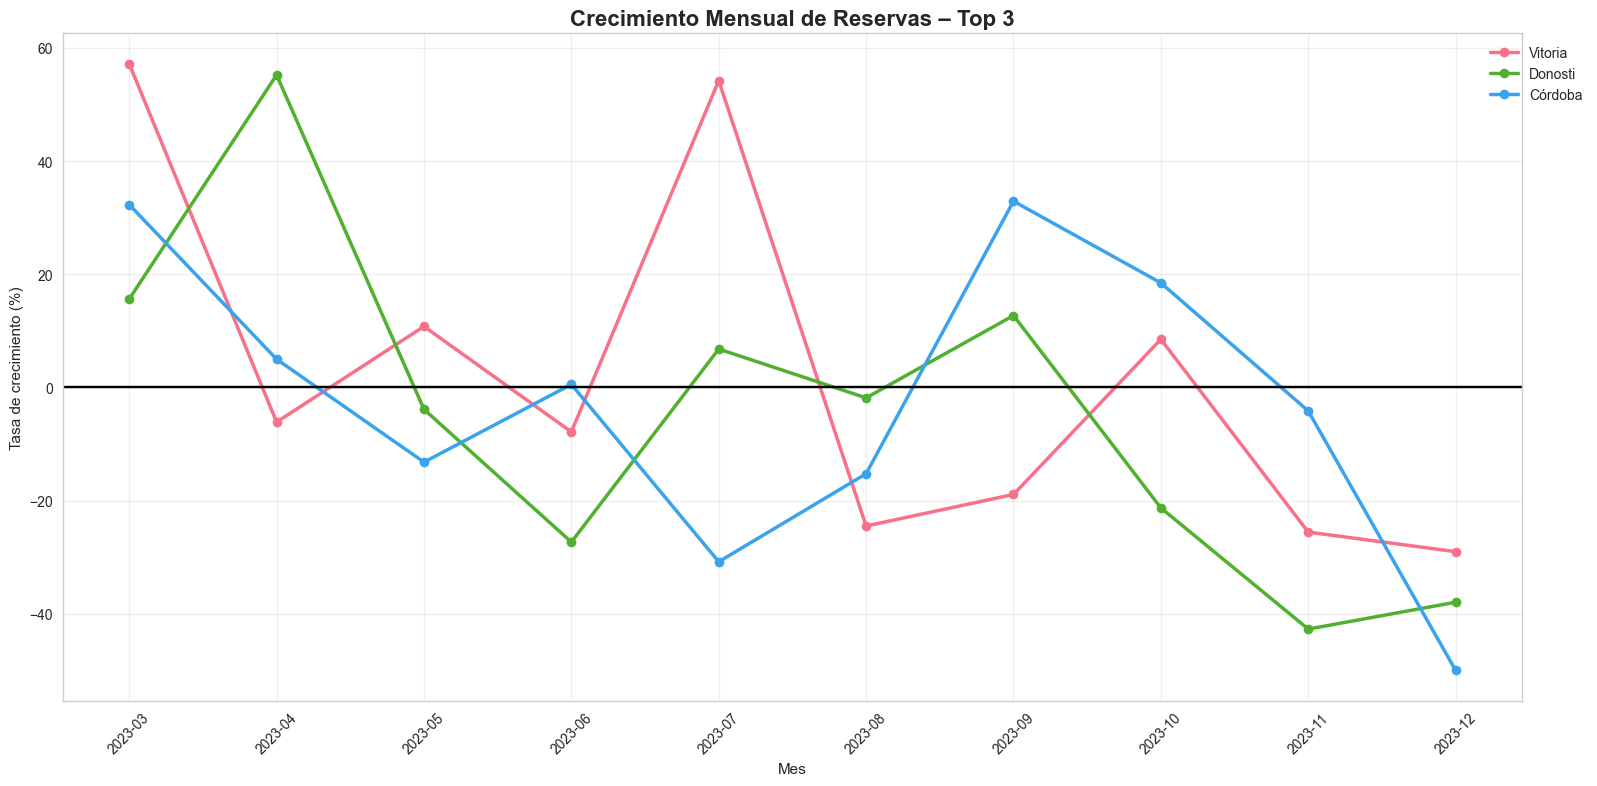


ANÁLISIS TOP 3 – RESERVAS

Vitoria
  Crecimiento medio: +1.9%
  Volatilidad: 31.5%
  Meses con crecimiento: 40.0%

Donosti
  Crecimiento medio: -4.5%
  Volatilidad: 29.4%
  Meses con crecimiento: 40.0%

Córdoba
  Crecimiento medio: -2.4%
  Volatilidad: 26.5%
  Meses con crecimiento: 50.0%


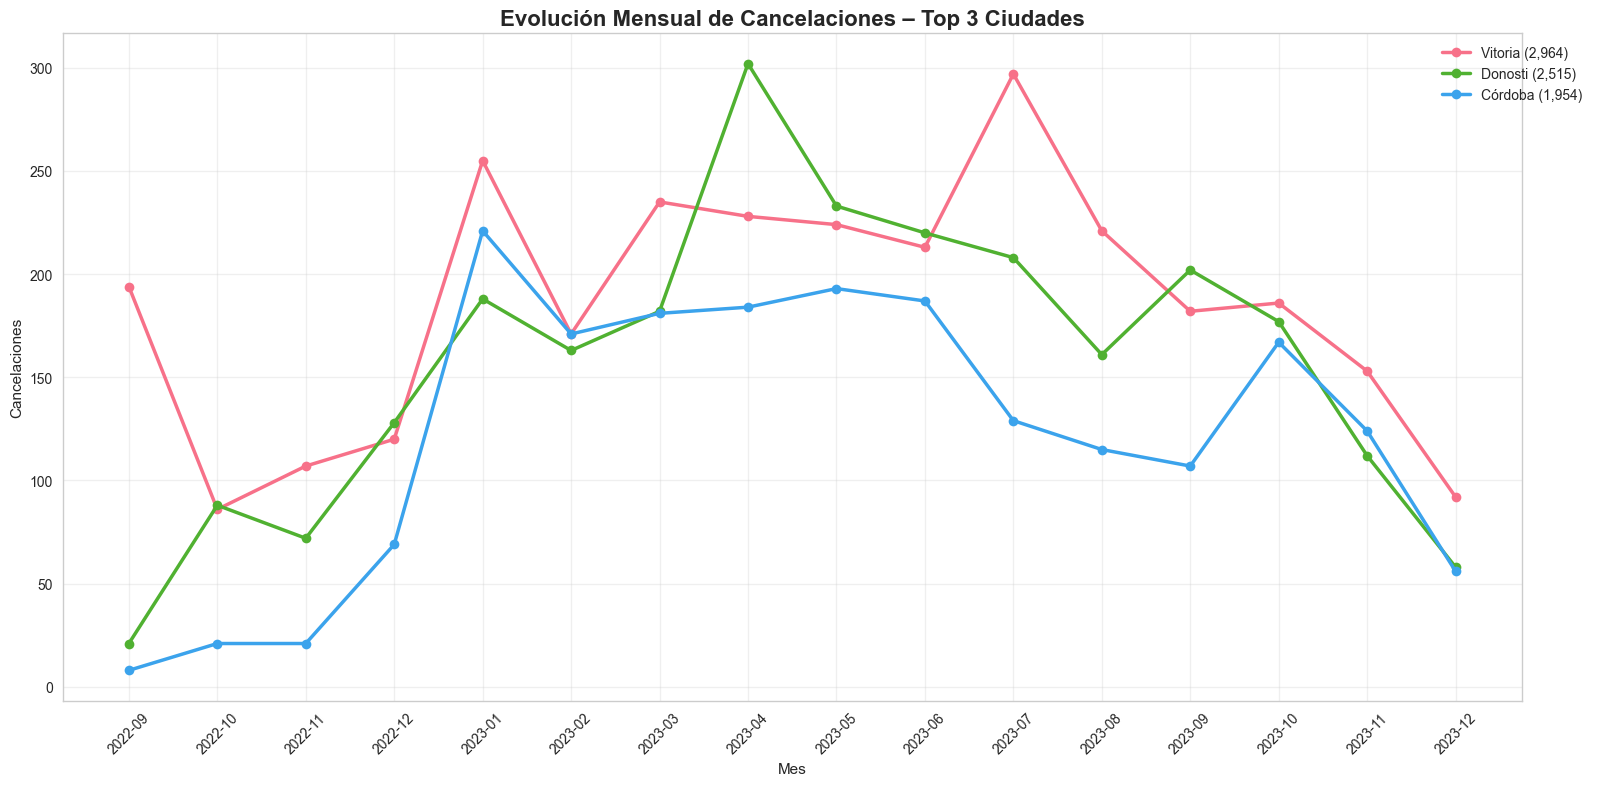

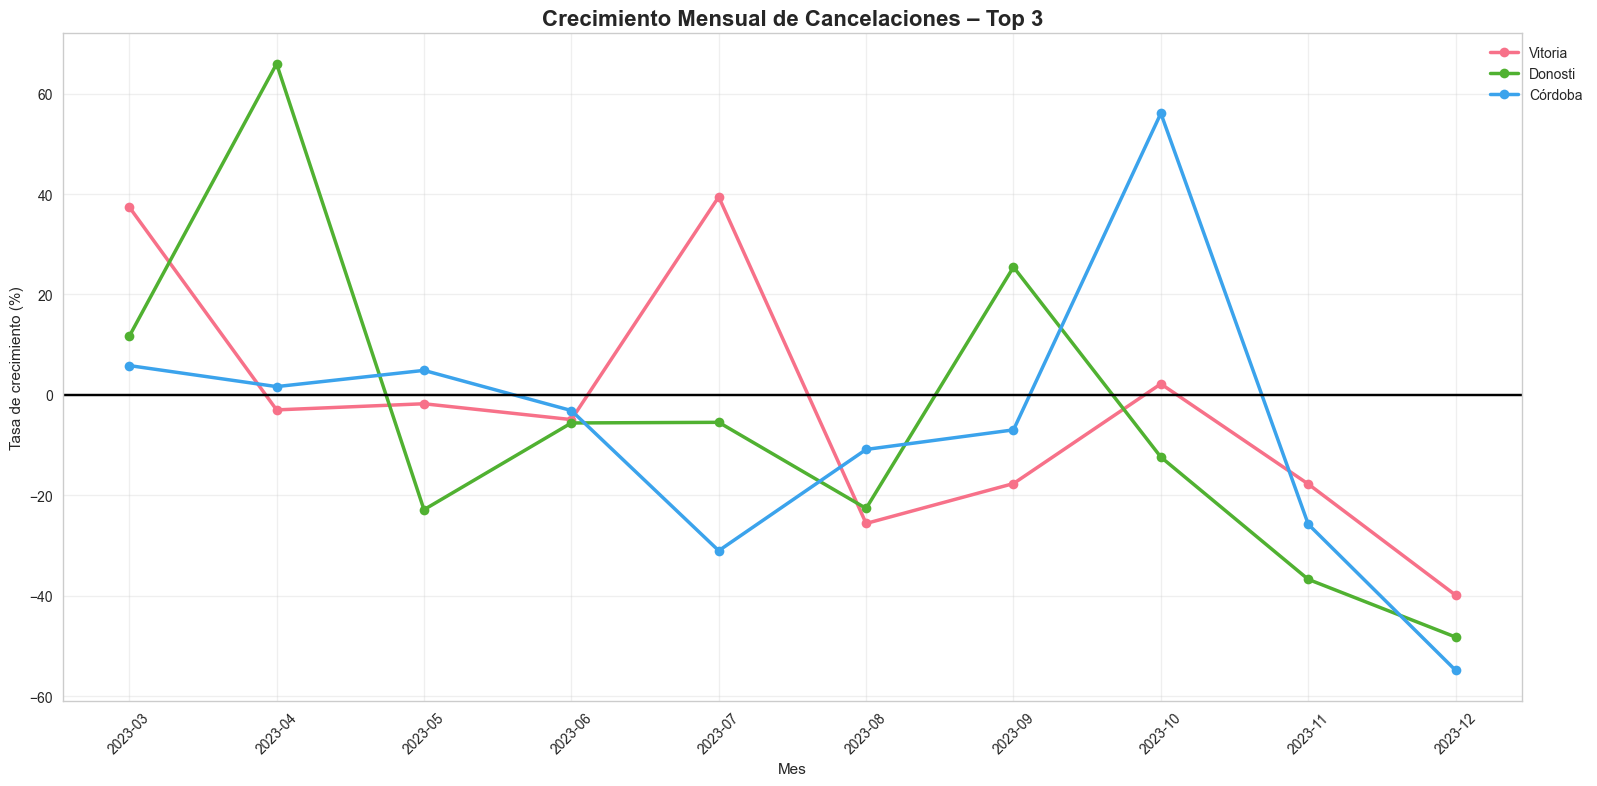


ANÁLISIS TOP 3 – CANCELACIONES (RIESGO)

Vitoria
  Crecimiento medio cancelaciones: -3.1%
  Volatilidad: 25.3%
  Meses con aumento de cancelaciones: 30.0%

Donosti
  Crecimiento medio cancelaciones: -5.1%
  Volatilidad: 33.0%
  Meses con aumento de cancelaciones: 30.0%

Córdoba
  Crecimiento medio cancelaciones: -6.4%
  Volatilidad: 29.1%
  Meses con aumento de cancelaciones: 40.0%


In [465]:
df['booked_at'] = pd.to_datetime(
    df['booked_at'],
    errors='coerce'
)

# Filtrar desde septiembre 2022
fecha_inicio = pd.Timestamp('2022-09-01')
df = df[df['booked_at'] >= fecha_inicio].copy()

# Crear columnas de periodo
df['mes_año'] = df['booked_at'].dt.to_period('M')
df['mes_año_str'] = df['mes_año'].astype(str)

# 2. AGRUPACIONES BASE
# Reservas
reservas_mes_ciudad = (
    df.groupby(['mes_año', 'ciudad'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Cancelaciones
cancelaciones_mes_ciudad = (
    df[df['status'] == 'cancelled']
    .groupby(['mes_año', 'ciudad'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 3. TOP 3 CIUDADES POR RESERVAS
total_reservas = reservas_mes_ciudad.sum().sort_values(ascending=False)
top3_res_ciudades = total_reservas.head(3).index.tolist()
top3_res_totales = total_reservas.head(3).values.tolist()

# 4. EVOLUCIÓN MENSUAL – TOP 3 RESERVAS
palette = sns.color_palette("husl", 3)
reservas_top3 = reservas_mes_ciudad[top3_res_ciudades]

plt.figure(figsize=(16, 8))
for i, ciudad in enumerate(top3_res_ciudades):
    plt.plot(
        reservas_top3.index.astype(str),
        reservas_top3[ciudad],
        marker='o',
        linewidth=2.5,
        color=palette[i],
        label=f"{ciudad} ({top3_res_totales[i]:,})"
    )

plt.title("Evolución Mensual de Reservas – Top 3 Ciudades", fontsize=16, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Reservas")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. TASAS DE CRECIMIENTO RESERVAS (desde Feb 2023)
fecha_tasas = pd.Period('2023-02', 'M')
reservas_top3_tasas = reservas_top3[reservas_top3.index >= fecha_tasas]

tasas_reservas = reservas_top3_tasas.pct_change() * 100
tasas_reservas = tasas_reservas.iloc[1:]

plt.figure(figsize=(16, 8))
for i, ciudad in enumerate(top3_res_ciudades):
    plt.plot(
        tasas_reservas.index.astype(str),
        tasas_reservas[ciudad],
        marker='o',
        linewidth=2.5,
        color=palette[i],
        label=ciudad
    )

plt.axhline(0, color='black')
plt.title("Crecimiento Mensual de Reservas – Top 3", fontsize=16, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Tasa de crecimiento (%)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. ANÁLISIS RESERVAS
print("\n" + "="*80)
print("ANÁLISIS TOP 3 – RESERVAS")
print("="*80)

for ciudad in top3_res_ciudades:
    media = tasas_reservas[ciudad].mean()
    volatilidad = tasas_reservas[ciudad].std()
    consistencia = (tasas_reservas[ciudad] > 0).mean() * 100

    print(f"\n{ciudad}")
    print(f"  Crecimiento medio: {media:+.1f}%")
    print(f"  Volatilidad: {volatilidad:.1f}%")
    print(f"  Meses con crecimiento: {consistencia:.1f}%")

# 7. TOP 3 CIUDADES POR CANCELACIONES
total_cancelaciones = cancelaciones_mes_ciudad.sum().sort_values(ascending=False)
top3_can_ciudades = total_cancelaciones.head(3).index.tolist()
top3_can_totales = total_cancelaciones.head(3).values.tolist()

# 8. EVOLUCIÓN MENSUAL – TOP 3 CANCELACIONES
cancelaciones_top3 = cancelaciones_mes_ciudad[top3_can_ciudades]

plt.figure(figsize=(16, 8))
for i, ciudad in enumerate(top3_can_ciudades):
    plt.plot(
        cancelaciones_top3.index.astype(str),
        cancelaciones_top3[ciudad],
        marker='o',
        linewidth=2.5,
        color=palette[i],
        label=f"{ciudad} ({top3_can_totales[i]:,})"
    )

plt.title("Evolución Mensual de Cancelaciones – Top 3 Ciudades", fontsize=16, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Cancelaciones")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9. TASAS DE CRECIMIENTO CANCELACIONES
cancelaciones_top3_tasas = cancelaciones_top3[cancelaciones_top3.index >= fecha_tasas]
tasas_cancelaciones = cancelaciones_top3_tasas.pct_change() * 100
tasas_cancelaciones = tasas_cancelaciones.iloc[1:]

plt.figure(figsize=(16, 8))
for i, ciudad in enumerate(top3_can_ciudades):
    plt.plot(
        tasas_cancelaciones.index.astype(str),
        tasas_cancelaciones[ciudad],
        marker='o',
        linewidth=2.5,
        color=palette[i],
        label=ciudad
    )

plt.axhline(0, color='black')
plt.title("Crecimiento Mensual de Cancelaciones – Top 3", fontsize=16, fontweight='bold')
plt.xlabel("Mes")
plt.ylabel("Tasa de crecimiento (%)")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 10. ANÁLISIS CANCELACIONES (RIESGO)
print("\n" + "="*80)
print("ANÁLISIS TOP 3 – CANCELACIONES (RIESGO)")
print("="*80)

for ciudad in top3_can_ciudades:
    media = tasas_cancelaciones[ciudad].mean()
    volatilidad = tasas_cancelaciones[ciudad].std()
    meses_suben = (tasas_cancelaciones[ciudad] > 0).mean() * 100

    print(f"\n{ciudad}")
    print(f"  Crecimiento medio cancelaciones: {media:+.1f}%")
    print(f"  Volatilidad: {volatilidad:.1f}%")
    print(f"  Meses con aumento de cancelaciones: {meses_suben:.1f}%")

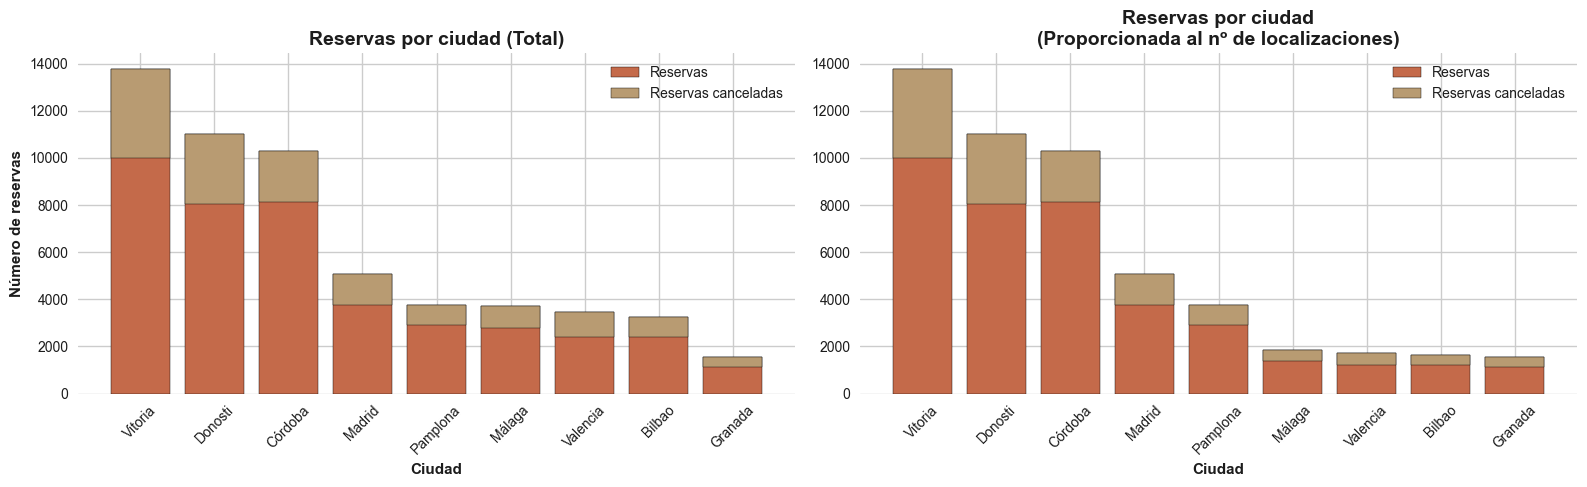

In [ ]:

# Resumen de reservas y cancelaciones por ciudad
# =========================
reservas_totales = df.groupby("ciudad").size()
reservas_canceladas = (
    df[df["status"] == 'cancelled']
    .groupby("ciudad")
    .size()
)

resumen = pd.DataFrame({
    "Reservas": reservas_totales,
    "Reservas canceladas": reservas_canceladas
}).fillna(0)

# Número de localizaciones únicas por ciudad
localizaciones = df.groupby("ciudad")["asset"].nunique()

# Preparar datos ordenados

# Gráfico 1: Total
resumen_total = resumen.sort_values(by="Reservas", ascending=False)

# Gráfico 2: Proporcional al nº de localizaciones
resumen_prop = resumen.div(localizaciones, axis=0)
resumen_prop = resumen_prop.sort_values(by="Reservas", ascending=False)

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# ---- Gráfico 1: Total ----
axes[0].bar(
    resumen_total.index,
    resumen_total["Reservas"],
    color=libere_true_graph_palette[5],
    edgecolor="black",
    label="Reservas"
)
axes[0].bar(
    resumen_total.index,
    resumen_total["Reservas canceladas"],
    bottom=resumen_total["Reservas"] - resumen_total["Reservas canceladas"],
    color=libere_true_graph_palette[2],
    edgecolor="black",
    label="Reservas canceladas"
)

axes[0].set_title("Reservas por ciudad (Total)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Ciudad", fontweight='bold')
axes[0].set_ylabel("Número de reservas", fontweight='bold')
axes[0].tick_params(axis="x", rotation=45, labelsize=10)
axes[0].legend()

# ---- Gráfico 2: Proporcional ----
axes[1].bar(
    resumen_prop.index,
    resumen_prop["Reservas"],
    color=libere_true_graph_palette[5],
    edgecolor="black",
    label="Reservas"
)
axes[1].bar(
    resumen_prop.index,
    resumen_prop["Reservas canceladas"],
    bottom=resumen_prop["Reservas"] - resumen_prop["Reservas canceladas"],
    color=libere_true_graph_palette[2],
    edgecolor="black",
    label="Reservas canceladas"
)

axes[1].set_title("Reservas por ciudad\n(Proporcionada al nº de localizaciones)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Ciudad", fontweight='bold')
axes[1].tick_params(axis="x", rotation=45, labelsize=10)
axes[1].legend()

plt.tight_layout()
plt.show()

      Graficos variables creadas manualmente

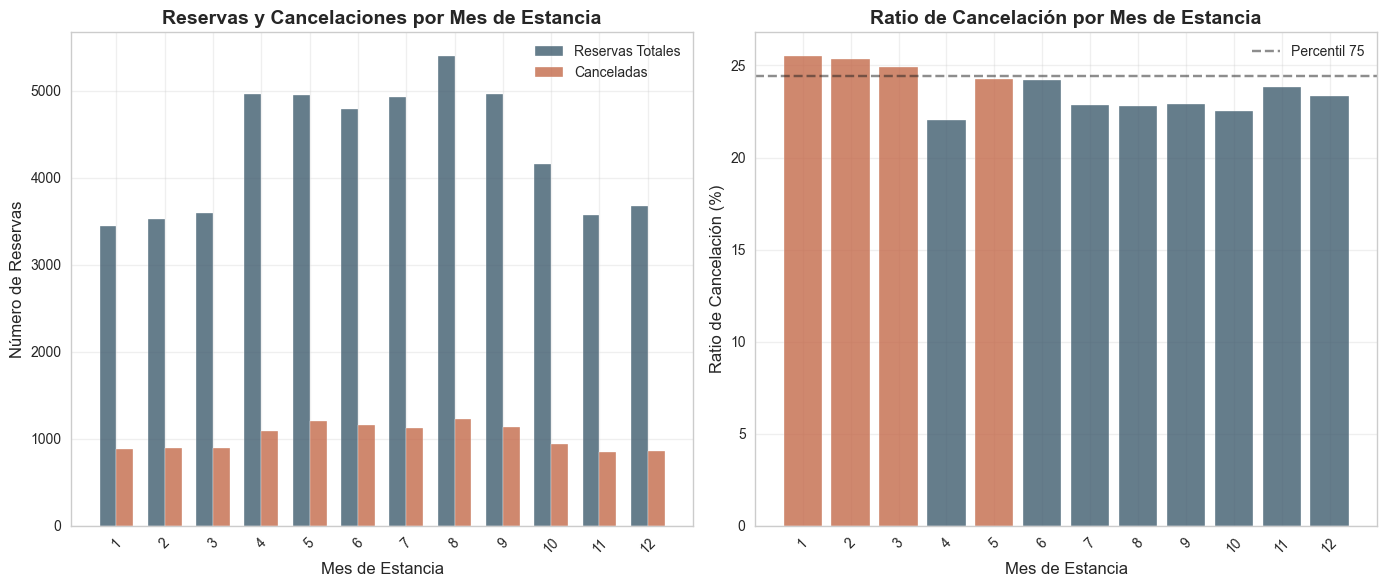

C:\Users\unaip\AppData\Local\Temp\ipykernel_10372\566092724.py:99: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_for_boxplot, patch_artist=True, labels=estaciones_orden)


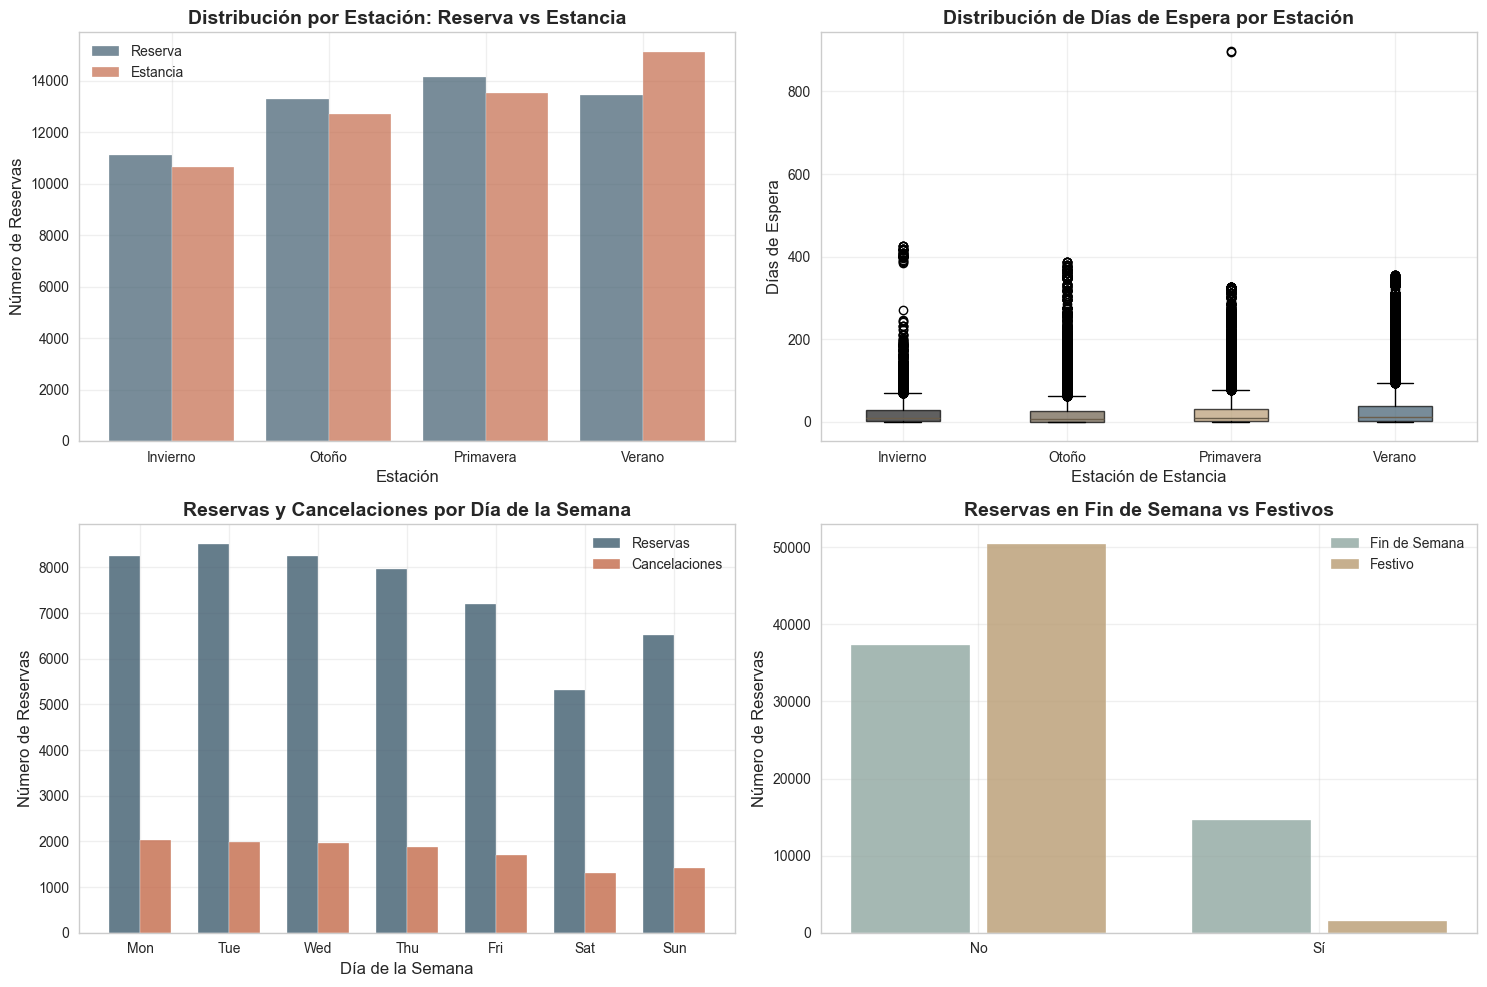

In [463]:
# Configurar estilo de matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(libere_true_graph_palette)

# Load datos
path_datos = os.path.join('Datos','Transformados')
filename = os.path.join(path_datos,'df_limpio.csv')
df = pd.read_csv(filename)
df['is_cancelled'] = df['status'] == 'cancelled'

# Convertir columnas de fecha a datetime
df['booked_at'] = pd.to_datetime(df['booked_at'])
df['checkin_time'] = pd.to_datetime(df['checkin_time'])
df['cancelled_at'] = pd.to_datetime(df['cancelled_at'], errors='coerce')

# GRÁFICO 1: Distribución de cancelaciones por mes de estancia
plt.figure(figsize=(14, 6))

# Subgráfico 1: Número de reservas y cancelaciones por mes de estancia
plt.subplot(1, 2, 1)

# Contar reservas totales y canceladas por mes de estancia
mes_estancia_counts = df['mes_estancia'].value_counts().sort_index()
cancelados_counts = df[df['is_cancelled'] == True]['mes_estancia'].value_counts().sort_index()

x = range(len(mes_estancia_counts))
width = 0.35

plt.bar([i - width/2 for i in x], mes_estancia_counts.values, width=width, 
        label='Reservas Totales', color=libere_true_graph_palette[3], alpha=0.8)
plt.bar([i + width/2 for i in x], cancelados_counts.reindex(mes_estancia_counts.index, fill_value=0).values, 
        width=width, label='Canceladas', color=libere_true_graph_palette[5], alpha=0.8)

plt.xlabel('Mes de Estancia', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.title('Reservas y Cancelaciones por Mes de Estancia', fontsize=14, fontweight='bold')
plt.xticks(x, mes_estancia_counts.index, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfico 2: Ratio de cancelación por mes de estancia
plt.subplot(1, 2, 2)

# Calcular ratio de cancelación por mes de estancia
cancelacion_ratio = (cancelados_counts / mes_estancia_counts * 100).fillna(0)

# Crear barras con colores según zona_roja
colors = [libere_true_graph_palette[5] if val else libere_true_graph_palette[3] 
          for val in df.drop_duplicates('mes_estancia').set_index('mes_estancia').loc[mes_estancia_counts.index, 'zona_roja']]

bars = plt.bar(range(len(cancelacion_ratio)), cancelacion_ratio.values, color=colors, alpha=0.8)

plt.xlabel('Mes de Estancia', fontsize=12)
plt.ylabel('Ratio de Cancelación (%)', fontsize=12)
plt.title('Ratio de Cancelación por Mes de Estancia', fontsize=14, fontweight='bold')
plt.xticks(range(len(cancelacion_ratio)), cancelacion_ratio.index, rotation=45)
plt.axhline(y=cancelacion_ratio.quantile(0.75), color=libere_true_graph_palette[0], 
            linestyle='--', alpha=0.5, label='Percentil 75')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# GRÁFICO 2: Distribución temporal y comparativa
plt.figure(figsize=(15, 10))

# Subgráfico 1: Distribución de estaciones de reserva vs estancia
plt.subplot(2, 2, 1)

# Preparar datos para stacked bar
estaciones = sorted(df['estacion_reserva'].unique())
estacion_counts_reserva = df['estacion_reserva'].value_counts().reindex(estaciones)
estacion_counts_estancia = df['estacion_estancia'].value_counts().reindex(estaciones)

x = range(len(estaciones))
plt.bar(x, estacion_counts_reserva.values, width=0.4, label='Reserva', 
        color=libere_true_graph_palette[3], alpha=0.7)
plt.bar([i + 0.4 for i in x], estacion_counts_estancia.values, width=0.4, label='Estancia', 
        color=libere_true_graph_palette[5], alpha=0.7)

plt.xlabel('Estación', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.title('Distribución por Estación: Reserva vs Estancia', fontsize=14, fontweight='bold')
plt.xticks([i + 0.2 for i in x], estaciones)
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfico 2: Días de espera por estación
plt.subplot(2, 2, 2)

# Boxplot de días de espera por estación de estancia
data_for_boxplot = []
estaciones_orden = sorted(df['estacion_estancia'].unique())

for estacion in estaciones_orden:
    data_for_boxplot.append(df[df['estacion_estancia'] == estacion]['espera_dias'].dropna())

box = plt.boxplot(data_for_boxplot, patch_artist=True, labels=estaciones_orden)

# Colorear las cajas con la paleta
colors_box = [libere_true_graph_palette[i % len(libere_true_graph_palette)] 
              for i in range(len(estaciones_orden))]
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xlabel('Estación de Estancia', fontsize=12)
plt.ylabel('Días de Espera', fontsize=12)
plt.title('Distribución de Días de Espera por Estación', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Subgráfico 3: Día de la semana más popular para reservar vs cancelar
plt.subplot(2, 2, 3)

dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
reserva_counts = df['dia_semana_reserva_nombre'].value_counts().reindex(dias_semana, fill_value=0)
cancelacion_counts = df[df['is_cancelled'] == True]['dia_semana_cancelacion_nombre'].value_counts().reindex(dias_semana, fill_value=0)

x = range(len(dias_semana))
width = 0.35

plt.bar([i - width/2 for i in x], reserva_counts.values, width=width, 
        label='Reservas', color=libere_true_graph_palette[3], alpha=0.8)
plt.bar([i + width/2 for i in x], cancelacion_counts.values, width=width, 
        label='Cancelaciones', color=libere_true_graph_palette[5], alpha=0.8)

plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.title('Reservas y Cancelaciones por Día de la Semana', fontsize=14, fontweight='bold')
plt.xticks(x, [d[:3] for d in dias_semana])
plt.legend()
plt.grid(True, alpha=0.3)

# Subgráfico 4: Comparación fin de semana vs festivo
plt.subplot(2, 2, 4)

# Preparar datos para comparación
weekend_data = df['es_finde'].value_counts().sort_index()
festivo_data = df['es_festivo'].value_counts().sort_index()

x = [0, 1]
labels = ['No', 'Sí']

plt.bar([i - 0.2 for i in x], weekend_data.values, width=0.35, 
        label='Fin de Semana', color=libere_true_graph_palette[4], alpha=0.8)
plt.bar([i + 0.2 for i in x], festivo_data.values, width=0.35, 
        label='Festivo', color=libere_true_graph_palette[2], alpha=0.8)

plt.xlabel('', fontsize=12)
plt.ylabel('Número de Reservas', fontsize=12)
plt.title('Reservas en Fin de Semana vs Festivos', fontsize=14, fontweight='bold')
plt.xticks(x, labels)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()